# *Data Describtion*



In [1]:
import pandas as pd
from autoimpute.imputations import SingleImputer
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.


In [3]:
df=pd.read_csv(r"Telco_Churn_Data.csv")
#df_orig=pd.read_csv(r"Telco_Churn_Data.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1.0,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34.0,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2.0,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45.0,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2.0,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7093 entries, 0 to 7092
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7093 non-null   object 
 1   gender            7093 non-null   object 
 2   SeniorCitizen     7093 non-null   int64  
 3   Partner           7093 non-null   object 
 4   Dependents        7093 non-null   object 
 5   tenure            7073 non-null   float64
 6   PhoneService      6940 non-null   object 
 7   MultipleLines     6927 non-null   object 
 8   InternetService   7093 non-null   object 
 9   OnlineSecurity    6951 non-null   object 
 10  OnlineBackup      6949 non-null   object 
 11  DeviceProtection  7093 non-null   object 
 12  TechSupport       6940 non-null   object 
 13  StreamingTV       7093 non-null   object 
 14  StreamingMovies   7093 non-null   object 
 15  Contract          7078 non-null   object 
 16  PaperlessBilling  6957 non-null   object 


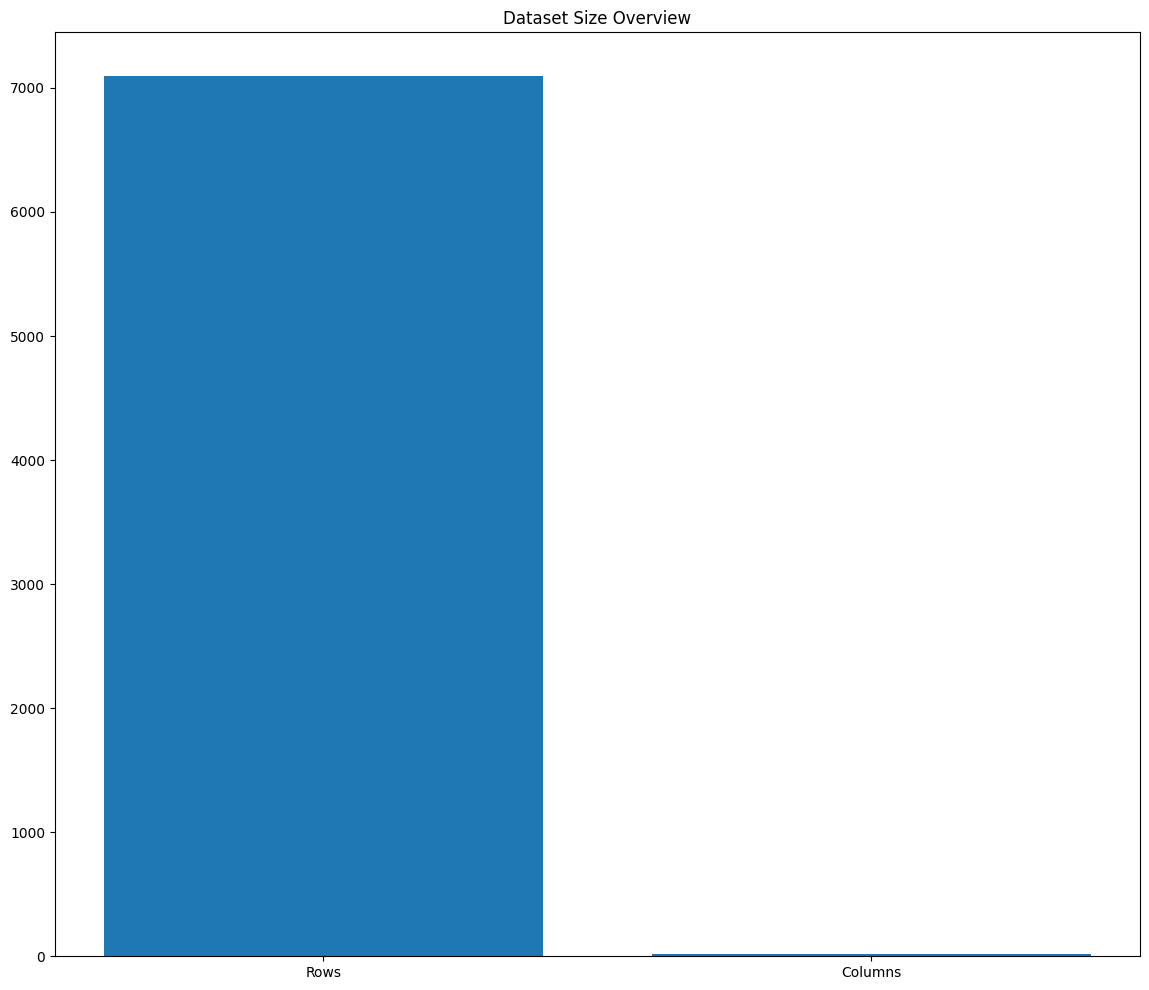

In [7]:
# ==========================================
# Dataset Overview Visualization
# Shows number of rows and columns visually
# Gives quick understanding of dataset size
# ==========================================

plt.figure(figsize=(14,12))
plt.bar(['Rows','Columns'], [df.shape[0], df.shape[1]])
plt.title("Dataset Size Overview")
plt.show()

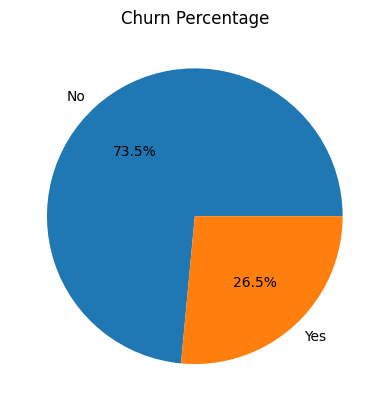

In [9]:
# ================================
# Churn Percentage Visualization
# This shows the proportion of each class in percentage form
# Gives clearer understanding of imbalance severity
# ================================

df['Churn'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Churn Percentage")
plt.ylabel("")
plt.show()

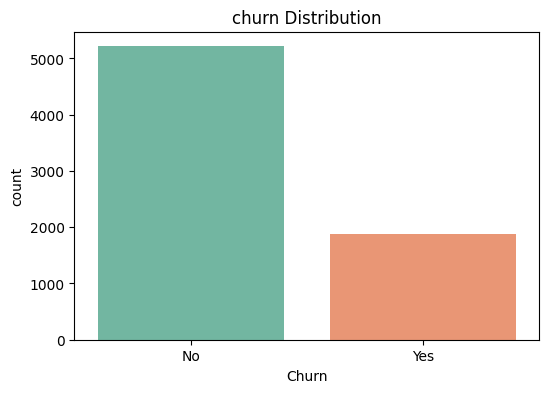

In [11]:
#churn count plot
plt.figure(figsize=(6,4))
sns.countplot(data=df,x="Churn",hue="Churn",palette="Set2",legend=False)
plt.title("churn Distribution")
plt.show()

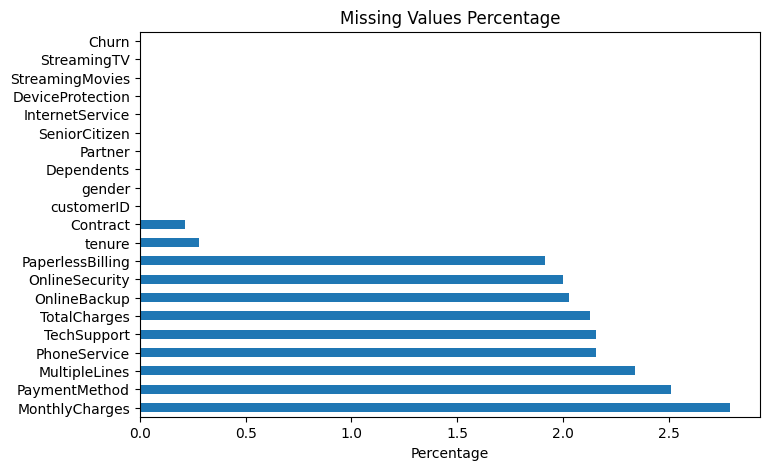

In [13]:
# ==========================================
# Missing Values Visualization
# Shows percentage of missing values per column
# Helps detect data quality problems
# ==========================================

missing_percent = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)

plt.figure(figsize=(8,5))
missing_percent.plot(kind='barh')
plt.title("Missing Values Percentage")
plt.xlabel("Percentage")
plt.show()

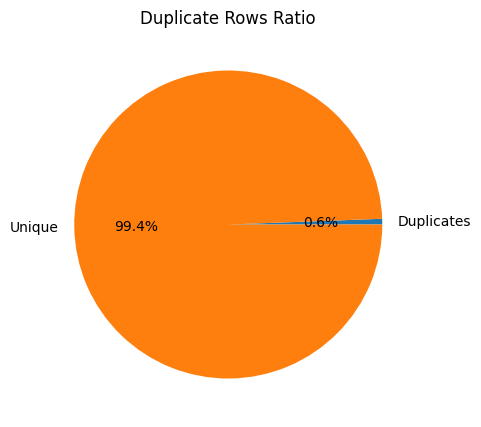

In [15]:
# ==========================================
# Duplicate Rows Overview
# Shows ratio of duplicate vs unique rows
# Ensures dataset integrity
# ==========================================

dup_count = df.duplicated().sum()

plt.figure(figsize=(5,5))
plt.pie([dup_count, len(df)-dup_count],
        labels=['Duplicates','Unique'],
        autopct='%1.1f%%')
plt.title("Duplicate Rows Ratio")
plt.show()

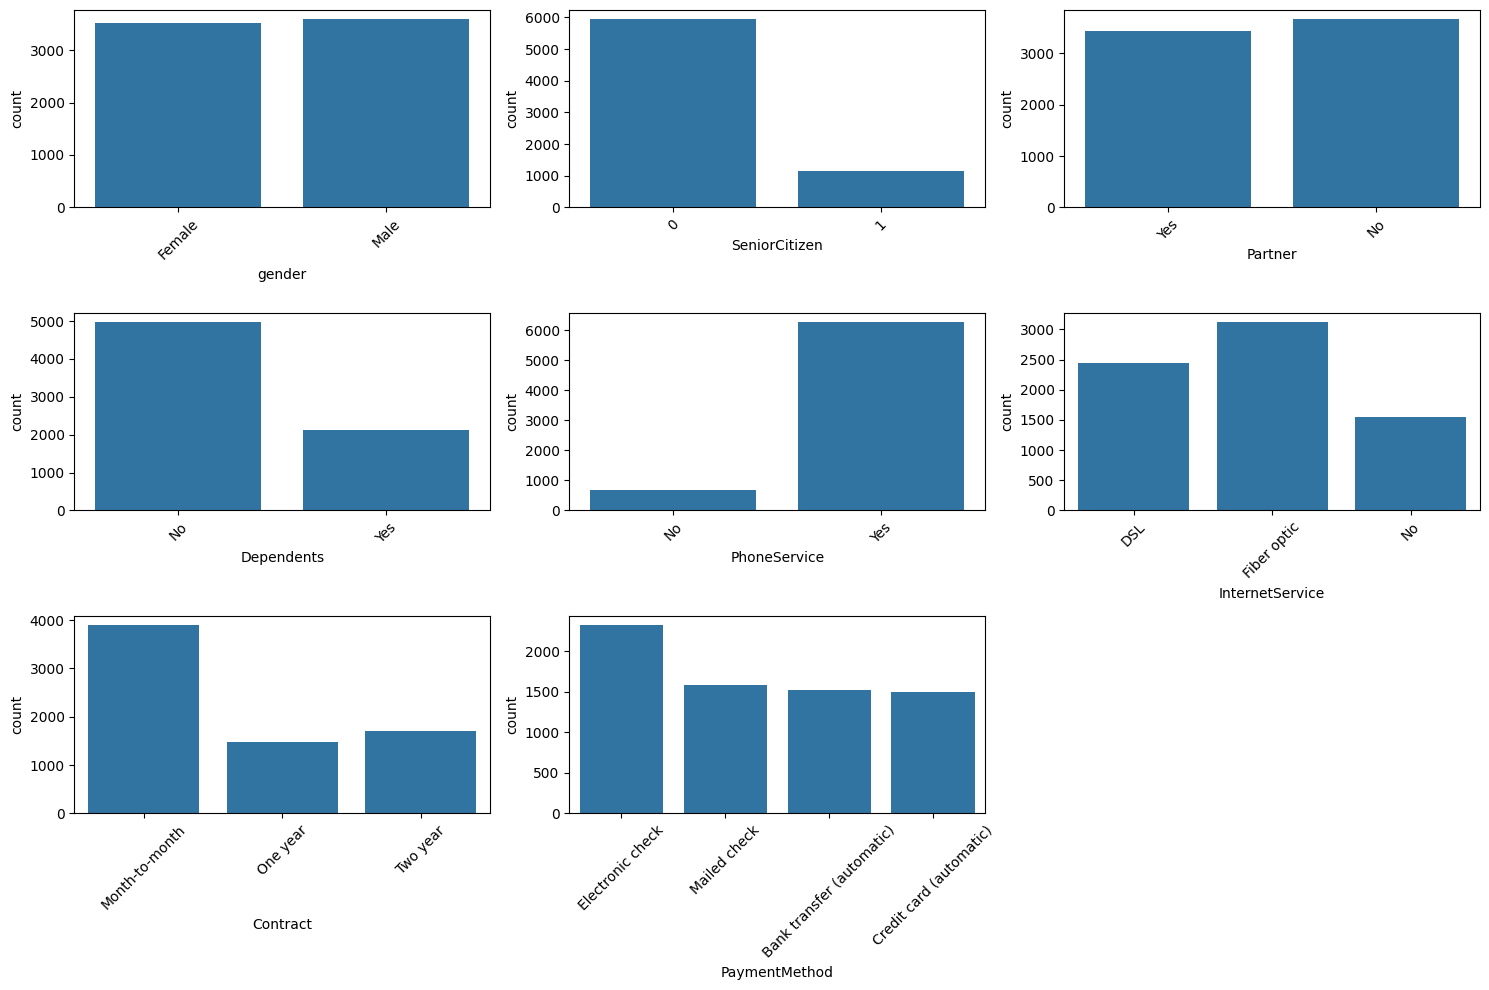

In [17]:
# ================================
# Categorical Features Distribution
# Shows frequency of each category in categorical columns
# Helps detect imbalance or rare categories
# ================================

cat_cols = ['gender','SeniorCitizen','Partner','Dependents',
            'PhoneService','InternetService','Contract','PaymentMethod']

plt.figure(figsize=(15,10))

for i,col in enumerate(cat_cols):
    plt.subplot(3,3,i+1)
    sns.countplot(x=col, data=df)
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

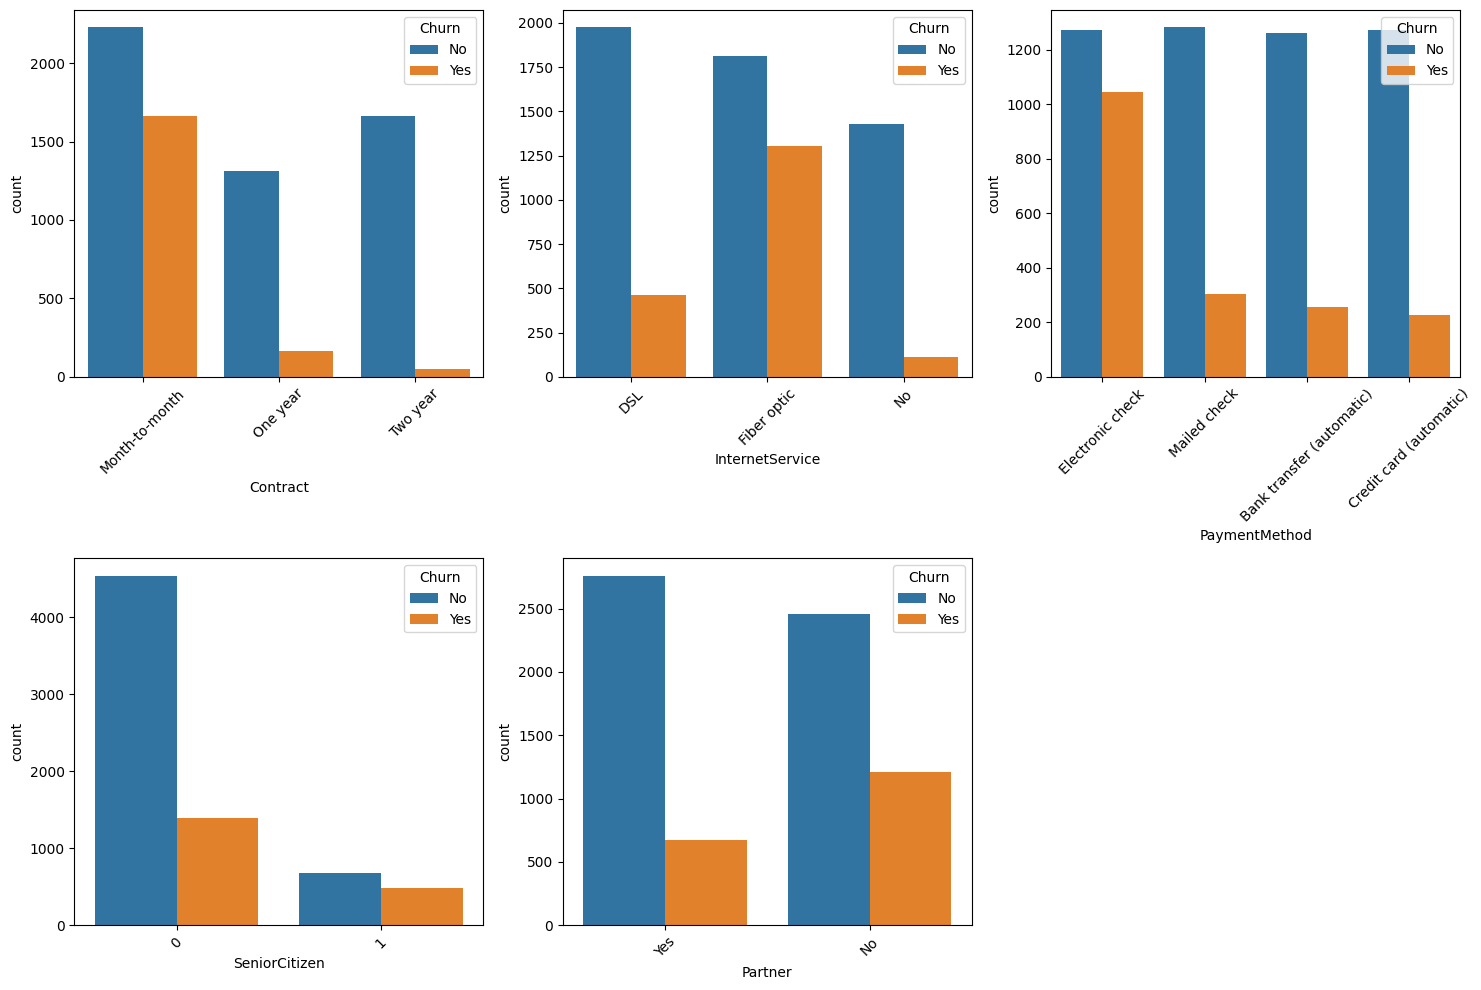

In [19]:
# ================================
# Categorical Features vs Churn
# Shows relationship between categorical variables and churn behavior
# Helps identify factors influencing customer cancellation
# ================================

important_cat = ['Contract','InternetService','PaymentMethod','SeniorCitizen','Partner']

plt.figure(figsize=(15,10))

for i,col in enumerate(important_cat):
    plt.subplot(2,3,i+1)
    sns.countplot(x=col, hue='Churn', data=df)
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

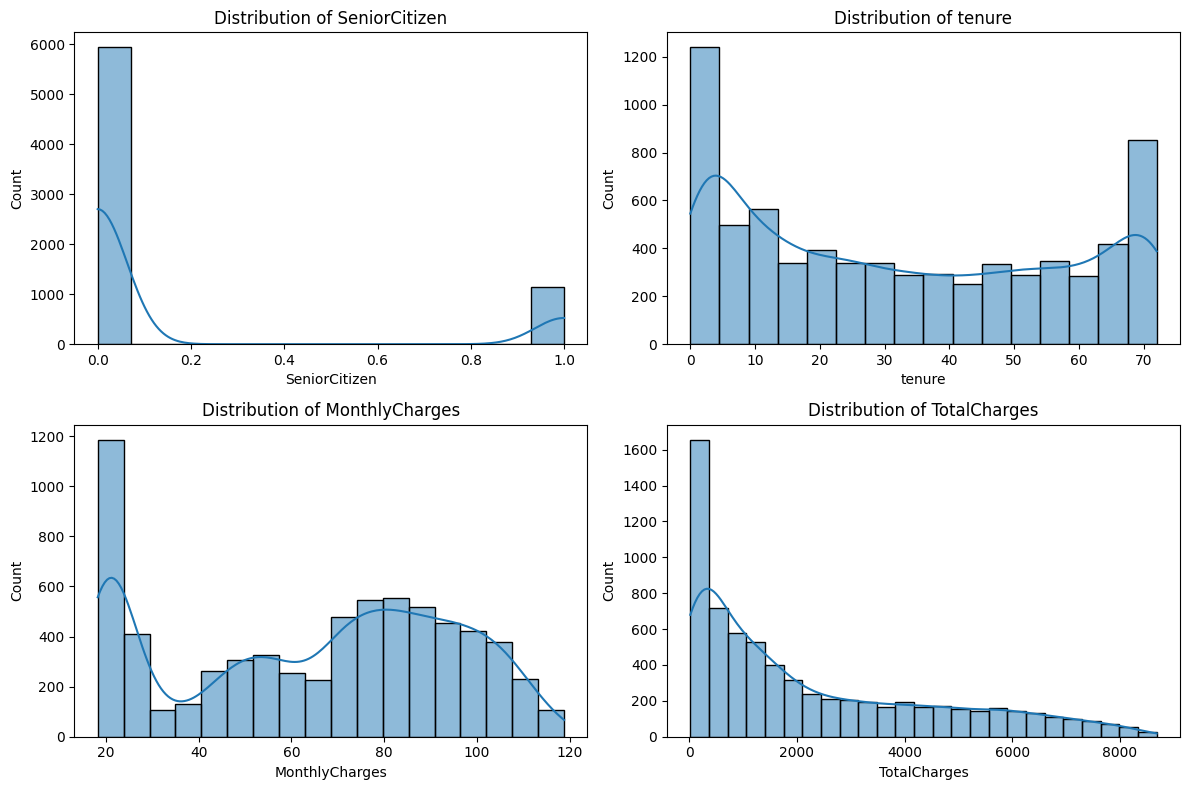

In [23]:
#Distribution of numerical features (note: should run the cell of totalcharge type convert)
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

plt.figure(figsize=(12,8))

for i, col in enumerate(num_cols):
    plt.subplot(2,2,i+1)
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")

plt.tight_layout()
plt.show()

C:\Users\Access\AppData\Local\Temp\ipykernel_3704\1670361882.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y=col, data=df_scaled,palette="Set3")
C:\Users\Access\AppData\Local\Temp\ipykernel_3704\1670361882.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y=col, data=df_scaled,palette="Set3")
C:\Users\Access\AppData\Local\Temp\ipykernel_3704\1670361882.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y=col, data=df_scaled,palette="Set3")
C:\Users\Access\AppData\Local\Temp\ipykernel_3704\16703618

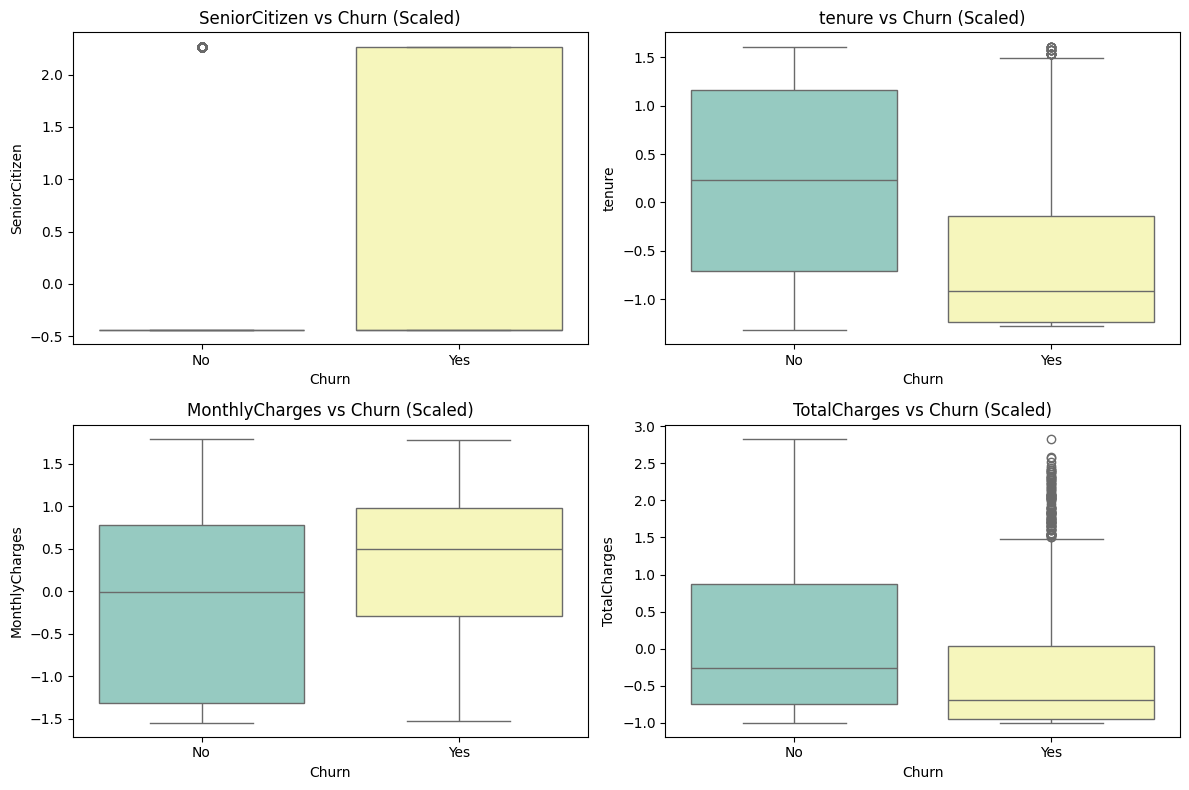

In [25]:
#numerical features vs churn

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# =========================
# Numerical features
# =========================
num_cols = ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

# =========================
# Scaling only
# =========================
scaler = StandardScaler()

df_scaled = df.copy()
df_scaled[num_cols] = scaler.fit_transform(df_scaled[num_cols])

# =========================
# Visualization
# =========================
plt.figure(figsize=(12,8))

for i, col in enumerate(num_cols):
    plt.subplot(2,2,i+1)
    sns.boxplot(x='Churn', y=col, data=df_scaled,palette="Set3")
    plt.title(f"{col} vs Churn (Scaled)")

plt.tight_layout()
plt.show()

# Data Cleaning


In [27]:
# remove CustomerID column
df.drop('customerID', axis=1, inplace=True) # because it is not useful for prediction

missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
quality_report = pd.DataFrame({
'Missing Count' : missing,
'Missing %'     : missing_pct
}).query('`Missing Count` > 0')

print("Missing Values:")
print(quality_report.to_string())
print(f"Duplicate rows: {df.duplicated().sum()}")

Missing Values:
                  Missing Count  Missing %
tenure                       20       0.28
PhoneService                153       2.16
MultipleLines               166       2.34
OnlineSecurity              142       2.00
OnlineBackup                144       2.03
TechSupport                 153       2.16
Contract                     15       0.21
PaperlessBilling            136       1.92
PaymentMethod               178       2.51
MonthlyCharges              198       2.79
TotalCharges                162       2.28
Duplicate rows: 56


## *Remove duplicated values*

In [29]:
before = len(df)
df.drop_duplicates(inplace=True)
after  = len(df)

print(f"Rows before : {before}")
print(f"Rows removed: {before - after}")
print(f"Rows after  : {after}")

Rows before : 7093
Rows removed: 56
Rows after  : 7037


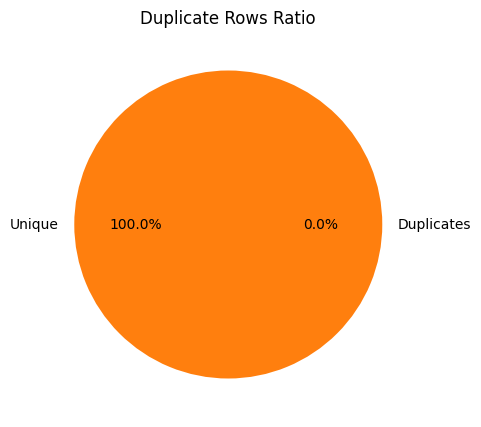

In [31]:
#After removing duplication
dup_count = df.duplicated().sum()

plt.figure(figsize=(5,5))
plt.pie([dup_count, len(df)-dup_count],
        labels=['Duplicates','Unique'],
        autopct='%1.1f%%')
plt.title("Duplicate Rows Ratio")
plt.show()

## *convert type of TotalCharges*



In [21]:
# type corrections
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
for col in df.columns:
    print(f"{col}: {df[col].unique()} unique values")


customerID: ['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK'] unique values
gender: ['Female' 'Male'] unique values
SeniorCitizen: [0 1] unique values
Partner: ['Yes' 'No'] unique values
Dependents: ['No' 'Yes'] unique values
tenure: [ 1. 34.  2. 45.  8. 22. 10. 28. 62. 13. 16. 58. 49. 25. 69. 52. 71. 21.
 12. 30. 47. 72. 17. 27.  5. 46. 11. 70. 63. 43. 15. 60. 18. 66.  9.  3.
 31. 50. 64. 56.  7. 42. 35. 48. 29. 65. 38. 68. 32. 55. 37. 36. 41.  6.
  4. 33. 67. 23. 57. 61. 14. 20. 53. nan 40. 59. 24. 44. 19. 54. 51. 26.
  0. 39.] unique values
PhoneService: ['No' 'Yes' nan] unique values
MultipleLines: ['No phone service' 'No' 'Yes' nan] unique values
InternetService: ['DSL' 'Fiber optic' 'No'] unique values
OnlineSecurity: ['No' 'Yes' 'No internet service' nan] unique values
OnlineBackup: ['Yes' nan 'No' 'No internet service'] unique values
DeviceProtection: ['No' 'Yes' 'No internet service'] unique values
TechSupport: ['No' 'Yes' 'No internet servic

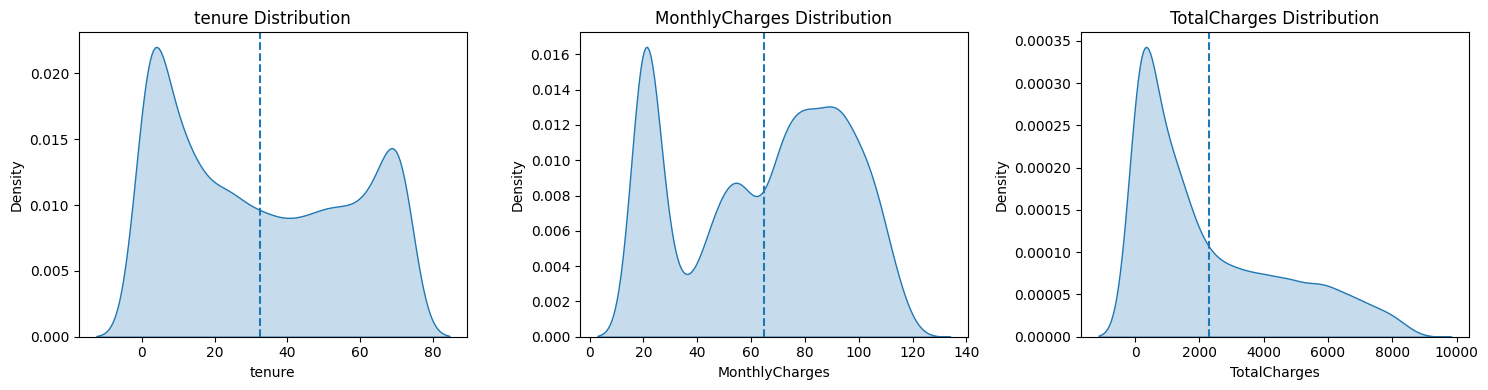

In [47]:
# ==========================================
# KDE Distribution Plot with Mean Line
# For each numerical feature separately
# Shows distribution shape + skewness + spread
# Adds mean line to understand central tendency
# ==========================================

num_cols = ['tenure','MonthlyCharges','TotalCharges']

plt.figure(figsize=(15,4))

for i, col in enumerate(num_cols):
    plt.subplot(1,3,i+1)
    
    # Density Curve
    sns.kdeplot(df[col].dropna(), fill=True)
    
    # Mean Line
    plt.axvline(df[col].mean(), linestyle='--')
    
    plt.title(f"{col} Distribution")
    plt.xlabel(col)
    plt.ylabel("Density")

plt.tight_layout()
plt.show()

## *Replace inconsistent values in some columns*


In [33]:
df.replace('No internet service', 'No', inplace=True)
df['PaymentMethod'] = df['PaymentMethod'].str.replace(r'\s*\(automatic\)', '', regex=True)
df['Contract'] = df['Contract'].replace('Month-to-month', 'Monthly')
df['MultipleLines']=df['MultipleLines'].replace('No phone service', 'No')
# print values of each column
for col in df.columns:
    print(f"{col}: {df[col].unique()} unique values")

gender: ['Female' 'Male'] unique values
SeniorCitizen: [0 1] unique values
Partner: ['Yes' 'No'] unique values
Dependents: ['No' 'Yes'] unique values
tenure: [ 1. 34.  2. 45.  8. 22. 10. 28. 62. 13. 16. 58. 49. 25. 69. 52. 71. 21.
 12. 30. 47. 72. 17. 27.  5. 46. 11. 70. 63. 43. 15. 60. 18. 66.  9.  3.
 31. 50. 64. 56.  7. 42. 35. 48. 29. 65. 38. 68. 32. 55. 37. 36. 41.  6.
  4. 33. 67. 23. 57. 61. 14. 20. 53. nan 40. 59. 24. 44. 19. 54. 51. 26.
  0. 39.] unique values
PhoneService: ['No' 'Yes' nan] unique values
MultipleLines: ['No' 'Yes' nan] unique values
InternetService: ['DSL' 'Fiber optic' 'No'] unique values
OnlineSecurity: ['No' 'Yes' nan] unique values
OnlineBackup: ['Yes' nan 'No'] unique values
DeviceProtection: ['No' 'Yes'] unique values
TechSupport: ['No' 'Yes' nan] unique values
StreamingTV: ['No' 'Yes'] unique values
StreamingMovies: ['No' 'Yes'] unique values
Contract: ['Monthly' 'One year' 'Two year' nan] unique values
PaperlessBilling: ['Yes' 'No' nan] unique values
P

## *Handle missing values*

In [36]:
missing_columns_category = [col for col in quality_report.index if df[col].dtype == 'object']
# hanle missing values
strategy_dict = {col: 'mode' for col in missing_columns_category}
df[missing_columns_category] = SingleImputer(
    strategy=strategy_dict,
    seed=42
).fit_transform(df[missing_columns_category])

# fill missing values in numerical columns using median per group
df['MonthlyCharges'] = df.groupby('InternetService')['MonthlyCharges'].transform(lambda x: x.fillna(x.median()))
df['tenure'] = df.groupby('Contract')['tenure'].transform(lambda x: x.fillna(x.median()))
df['tenure'] = df['tenure'].round().astype(int)
#spacial case fot total charges because it is related to tenure and monthley charges (if tenure is 0 then total charges eqal monthley charges)
mask_tc = df['TotalCharges'].isnull() & (df['tenure'] == 0)
df.loc[mask_tc, 'TotalCharges'] = df.loc[mask_tc, 'MonthlyCharges']

df['TotalCharges'] = df['TotalCharges'].fillna(
    df['tenure'] * df['MonthlyCharges'])

print("Number of missing values:\n", df.isnull().sum())
df.head()


Number of missing values:
 gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No,DSL,No,Yes,No,No,No,No,Monthly,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Monthly,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer,42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Monthly,Yes,Electronic check,70.70,151.65,Yes


In [38]:
pivot = pd.pivot_table(
df,
values   = 'MonthlyCharges',
index    = 'Contract',
columns  = 'InternetService',
aggfunc  = 'mean'
).round(2)

print("Average Monthly Charges by Contract x Internet Service:")
print(pivot.head())

# Churn Rate per Contract type
churn_pivot = pd.pivot_table(
df,
values  = 'Churn',
index   = 'Contract',
aggfunc = lambda x: (x == 'Yes').sum() / len(x) * 100
).round(2)
churn_pivot.columns = ['Churn Rate %']
print(r"\nChurn Rate % by Contract Type:")
print(churn_pivot.head())

Average Monthly Charges by Contract x Internet Service:
InternetService    DSL  Fiber optic     No
Contract                                  
Monthly          50.51        87.26  20.39
One year         61.14        98.64  20.82
Two year         70.16       104.19  21.71
\nChurn Rate % by Contract Type:
          Churn Rate %
Contract              
Monthly          42.64
One year         11.10
Two year          2.83


# *Encoding*

In [40]:
# Binary
binary_cols = [col for col in df.columns if df[col].nunique() == 2 and df[col].dtype == 'object']
for col in binary_cols:
    df[col] = df[col].map({'Yes':1, 'No':0, 'Male':1, 'Female':0})
# Ordinal data
df['Contract'] = df['Contract'].map({
    'Monthly': 0,
    'One year': 1,
    'Two year': 2
})

# One Hot
df= pd.get_dummies(df, columns=[
    'InternetService',
    'PaymentMethod',
    'MultipleLines'
],dtype=int)


df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,...,Churn,InternetService_DSL,InternetService_Fiber optic,InternetService_No,PaymentMethod_Bank transfer,PaymentMethod_Credit card,PaymentMethod_Electronic check,PaymentMethod_Mailed check,MultipleLines_0,MultipleLines_1
0,0,0,1,0,1,0,0,1,0,0,...,0,1,0,0,0,0,1,0,1,0
1,1,0,0,0,34,1,1,0,1,0,...,0,1,0,0,0,0,0,1,1,0
2,1,0,0,0,2,1,1,1,0,0,...,1,1,0,0,0,0,0,1,1,0
3,1,0,0,0,45,0,1,0,1,1,...,0,1,0,0,1,0,0,0,1,0
4,0,0,0,0,2,1,0,0,0,0,...,1,0,1,0,0,0,1,0,1,0


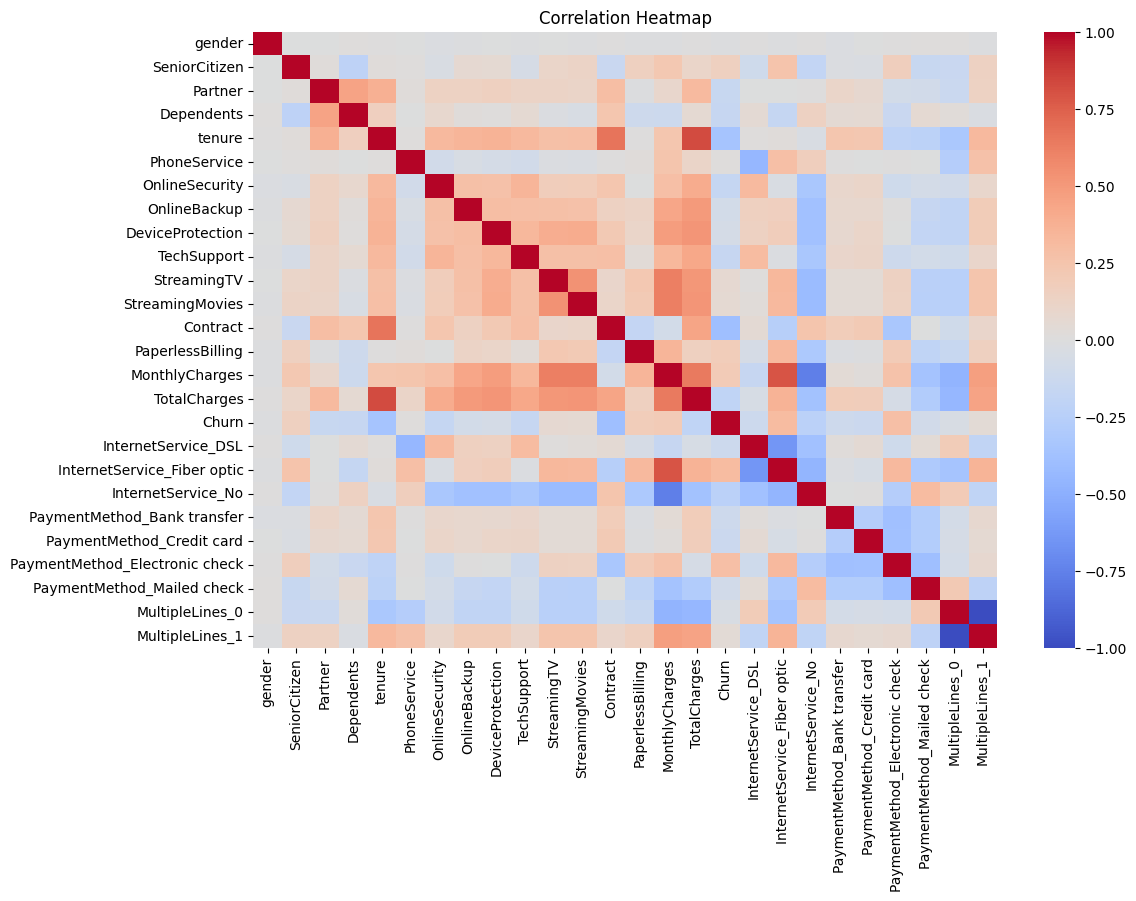

In [42]:
#correlation & features importance
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm', annot=False)
plt.title("Correlation Heatmap")
plt.show()

In [44]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(subset=['TotalCharges'], inplace=True)

def tenure_group(t):
    if t <= 12: return '0-1 Year'
    elif t <= 24: return '1-2 Years'
    elif t <= 48: return '2-4 Years'
    else: return '> 4 Years'

df['TenureGroup'] = df['tenure'].apply(tenure_group)

churn_summary = df.groupby('TenureGroup')['Churn'].value_counts(normalize=True).unstack()

churn_col = 'Yes' if 'Yes' in churn_summary.columns else 1
churn_rate = churn_summary[churn_col] * 100



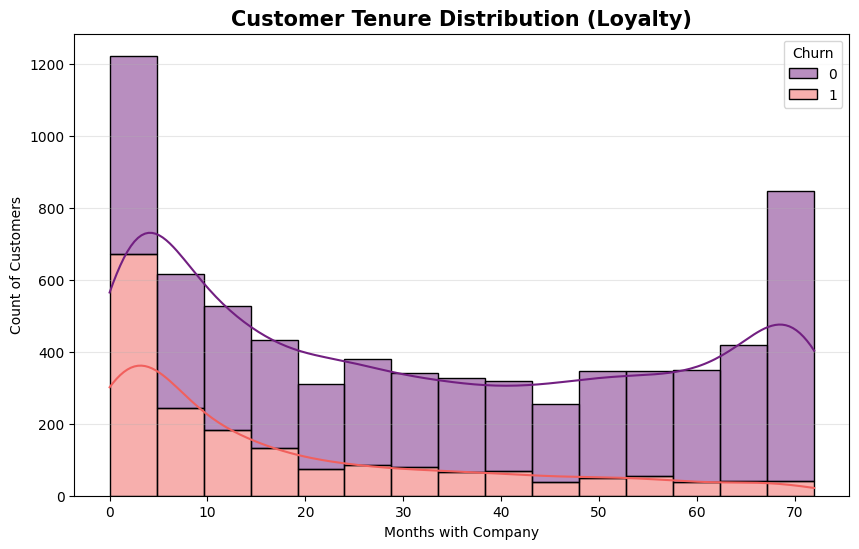

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

sns.histplot(data=df, x='tenure', hue='Churn', kde=True, multiple="stack", palette='magma')

plt.title('Customer Tenure Distribution (Loyalty)', fontsize=15, fontweight='bold')
plt.xlabel('Months with Company')
plt.ylabel('Count of Customers')
plt.grid(axis='y', alpha=0.3)
plt.show()

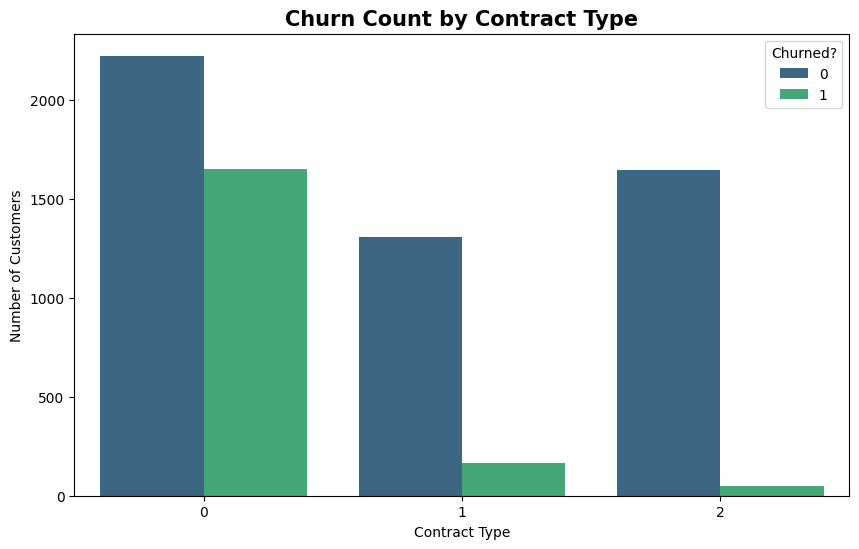

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

sns.countplot(data=df, x='Contract', hue='Churn', palette='viridis')

plt.title('Churn Count by Contract Type', fontsize=15, fontweight='bold')
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')
plt.legend(title='Churned?')
plt.show()

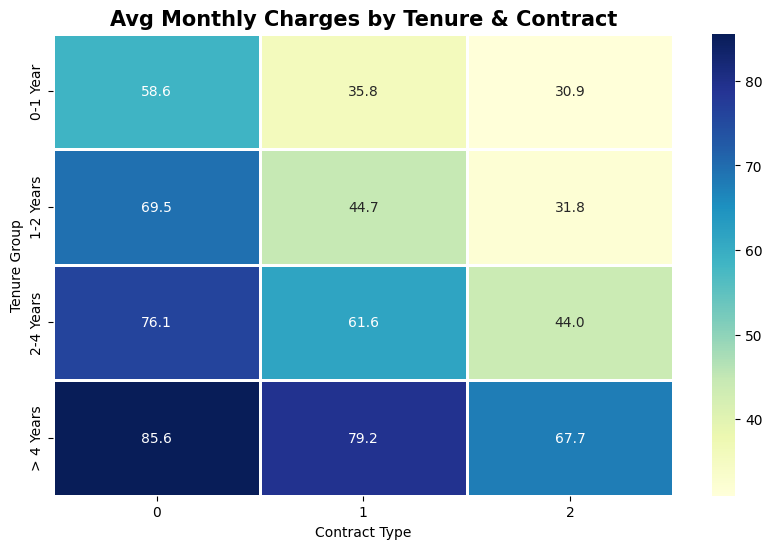

In [50]:
import seaborn as sns
import matplotlib.pyplot as plt


pivot_table = df.pivot_table(index='TenureGroup', columns='Contract', values='MonthlyCharges', aggfunc='mean')

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_table, annot=True, cmap='YlGnBu', fmt='.1f', linewidths=1)

plt.title('Avg Monthly Charges by Tenure & Contract', fontsize=15, fontweight='bold')
plt.xlabel('Contract Type')
plt.ylabel('Tenure Group')
plt.show()

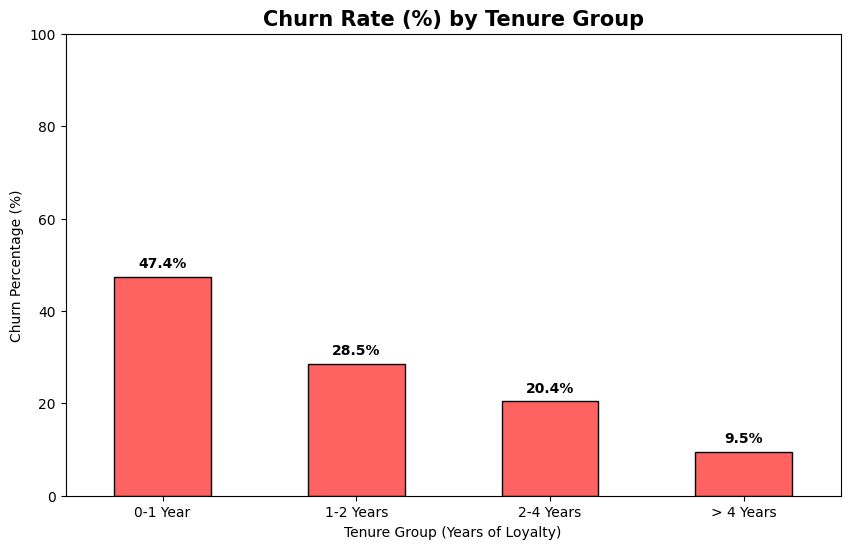

In [52]:
import matplotlib.pyplot as plt


churn_summary = df.groupby('TenureGroup')['Churn'].value_counts(normalize=True).unstack()

churn_col = 'Yes' if 'Yes' in churn_summary.columns else 1
churn_rate = churn_summary[churn_col] * 100

plt.figure(figsize=(10, 6))
churn_rate.plot(kind='bar', color='#ff6361', edgecolor='black', rot=0)

plt.title('Churn Rate (%) by Tenure Group', fontsize=15, fontweight='bold')
plt.xlabel('Tenure Group (Years of Loyalty)')
plt.ylabel('Churn Percentage (%)')
plt.ylim(0, 100) 

for i, v in enumerate(churn_rate):
    plt.text(i, v + 2, f'{v:.1f}%', ha='center', fontweight='bold')

plt.show()

In [144]:
df.info()
df.to_csv("cleaned_data.csv",index=False)

<class 'pandas.core.frame.DataFrame'>
Index: 7037 entries, 0 to 7091
Data columns (total 39 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   gender                          7037 non-null   int64  
 1   SeniorCitizen                   7037 non-null   int64  
 2   Partner                         7037 non-null   int64  
 3   Dependents                      7037 non-null   int64  
 4   tenure                          7037 non-null   int64  
 5   PhoneService                    7037 non-null   int64  
 6   OnlineSecurity                  7037 non-null   int64  
 7   OnlineBackup                    7037 non-null   int64  
 8   DeviceProtection                7037 non-null   int64  
 9   TechSupport                     7037 non-null   int64  
 10  StreamingTV                     7037 non-null   int64  
 11  StreamingMovies                 7037 non-null   int64  
 12  Contract                        7037 no

In [56]:
# print values of each column
for col in df.columns:
    print(f"{col}: {df[col].unique()} unique values")

gender: [0 1] unique values
SeniorCitizen: [0 1] unique values
Partner: [1 0] unique values
Dependents: [0 1] unique values
tenure: [ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26  0
 39] unique values
PhoneService: [0 1] unique values
OnlineSecurity: [0 1] unique values
OnlineBackup: [1 0] unique values
DeviceProtection: [0 1] unique values
TechSupport: [0 1] unique values
StreamingTV: [0 1] unique values
StreamingMovies: [0 1] unique values
Contract: [0 1 2] unique values
PaperlessBilling: [1 0] unique values
MonthlyCharges: [29.85 56.95 53.85 ... 63.1  44.2  78.7 ] unique values
TotalCharges: [  29.85 1889.5   108.15 ...  346.45  306.6  6844.5 ] unique values
Churn: [0 1] unique values
InternetService_DSL: [1 0] unique values
InternetService_Fiber optic: [0 1] unique values
InternetService_No: [0 1] unique values
Paym

# Feature Extraction

In [58]:
service_cols = [
    'PhoneService', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies'
]

df['TotalServices'] = df[service_cols].sum(axis=1)
print(df[['TotalServices']].head())

   TotalServices
0              1
1              3
2              3
3              3
4              1


In [60]:
df['AvgMonthlySpend'] = df['TotalCharges'] / (df['tenure'] + 1)
print(df[['AvgMonthlySpend']].head())

   AvgMonthlySpend
0        14.925000
1        53.985714
2        36.050000
3        40.016304
4        50.550000


In [62]:
df['TenureGroup'] = pd.cut(
    df['tenure'],
    bins=[-1, 12, 36, 100],
    labels=[0, 1, 2]
).astype(int)
print(df[['TenureGroup']].head())

   TenureGroup
0            0
1            1
2            0
3            2
4            0


In [64]:
df['HighValueCustomer'] = (df['MonthlyCharges'] > df['MonthlyCharges'].median()).astype(int)
print(df[['HighValueCustomer']].head())

   HighValueCustomer
0                  0
1                  0
2                  0
3                  0
4                  1


In [66]:
df['ContractRisk'] = df['Contract'].apply(lambda x: 2 if x == 0 else (1 if x == 1 else 0))
print(df[['ContractRisk']].head())

   ContractRisk
0             2
1             1
2             2
3             1
4             2


In [68]:
df['Charge_Tenure_Interaction'] = df['MonthlyCharges'] * df['tenure']
print(df[['Charge_Tenure_Interaction']].head())

   Charge_Tenure_Interaction
0                      29.85
1                    1936.30
2                     107.70
3                    1903.50
4                     141.40


In [70]:
import numpy as np

df['LogMonthlyCharges'] = np.log1p(df['MonthlyCharges'])
df['LogTotalCharges'] = np.log1p(df['TotalCharges'])

print(df[['MonthlyCharges', 'LogMonthlyCharges']].head())
print(df[['TotalCharges', 'LogTotalCharges']].head())

   MonthlyCharges  LogMonthlyCharges
0           29.85           3.429137
1           56.95           4.059581
2           53.85           4.004602
3           42.30           3.768153
4           70.70           4.272491
   TotalCharges  LogTotalCharges
0         29.85         3.429137
1       1889.50         7.544597
2        108.15         4.692723
3       1840.75         7.518471
4        151.65         5.028148


In [72]:
df['ChargesPerTenure'] = df['TotalCharges'] / (df['tenure'] + 1)
df['MonthlyToTotalRatio'] = df['MonthlyCharges'] / (df['TotalCharges'] + 1)

print(df[['ChargesPerTenure']].head())
print(df[['MonthlyToTotalRatio']].head())

   ChargesPerTenure
0         14.925000
1         53.985714
2         36.050000
3         40.016304
4         50.550000
   MonthlyToTotalRatio
0             0.967585
1             0.030124
2             0.493358
3             0.022967
4             0.463151


In [74]:
df['ExpectedVsActualCharges'] = df['MonthlyCharges'] * df['tenure'] - df['TotalCharges']

print(df[['ExpectedVsActualCharges']].head())

   ExpectedVsActualCharges
0                     0.00
1                    46.80
2                    -0.45
3                    62.75
4                   -10.25


In [76]:
df['ServiceEfficiency'] = df['TotalCharges'] / (df['TotalServices'] + 1)

print(df[['ServiceEfficiency']].head())

   ServiceEfficiency
0            14.9250
1           472.3750
2            27.0375
3           460.1875
4            75.8250


In [78]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X = df.drop('Churn', axis=1)
y = df['Churn']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=5)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=['PC1','PC2','PC3','PC4','PC5'])

pca_df['Churn'] = y.values

pca_df.head()

,PC1,PC2,PC3,PC4,PC5,Churn
0,-4.828710,-1.435366,2.699284,-1.732644,0.111019,0
1,-1.116337,1.352321,1.771930,0.756932,0.668057,0
2,-3.375597,-1.204144,2.499306,1.178334,1.230570,1
3,-0.768264,2.627825,3.179457,-1.746859,0.796868,0
4,-2.530791,-3.564568,-0.440610,-0.131715,-0.881365,1


In [80]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
X = df.drop('Churn', axis=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['CustomerCluster'] = kmeans.fit_predict(X_scaled)

df[['CustomerCluster']].head()

,CustomerCluster
0,1
1,1
2,1
3,1
4,1


In [82]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler

num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

X_num = df[num_cols]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_num)

poly = PolynomialFeatures(degree=2, include_bias=False)

X_poly = poly.fit_transform(X_scaled)

poly_df = pd.DataFrame(X_poly, columns=poly.get_feature_names_out(num_cols))

poly_df.head()

,tenure,MonthlyCharges,TotalCharges,tenure^2,tenure MonthlyCharges,tenure TotalCharges,MonthlyCharges^2,MonthlyCharges TotalCharges,TotalCharges^2
0,-1.280885,-1.164399,-0.994707,1.640667,1.491461,1.274105,1.355824,1.158236,0.989442
1,0.063490,-0.262304,-0.174719,0.004031,-0.016654,-0.011093,0.068803,0.045830,0.030527
2,-1.240146,-0.365495,-0.960182,1.537963,0.453268,1.190766,0.133587,0.350942,0.921949
3,0.511615,-0.749968,-0.196215,0.261750,-0.383695,-0.100387,0.562451,0.147155,0.038500
4,-1.240146,0.195401,-0.941001,1.537963,-0.242326,1.166979,0.038182,-0.183873,0.885483


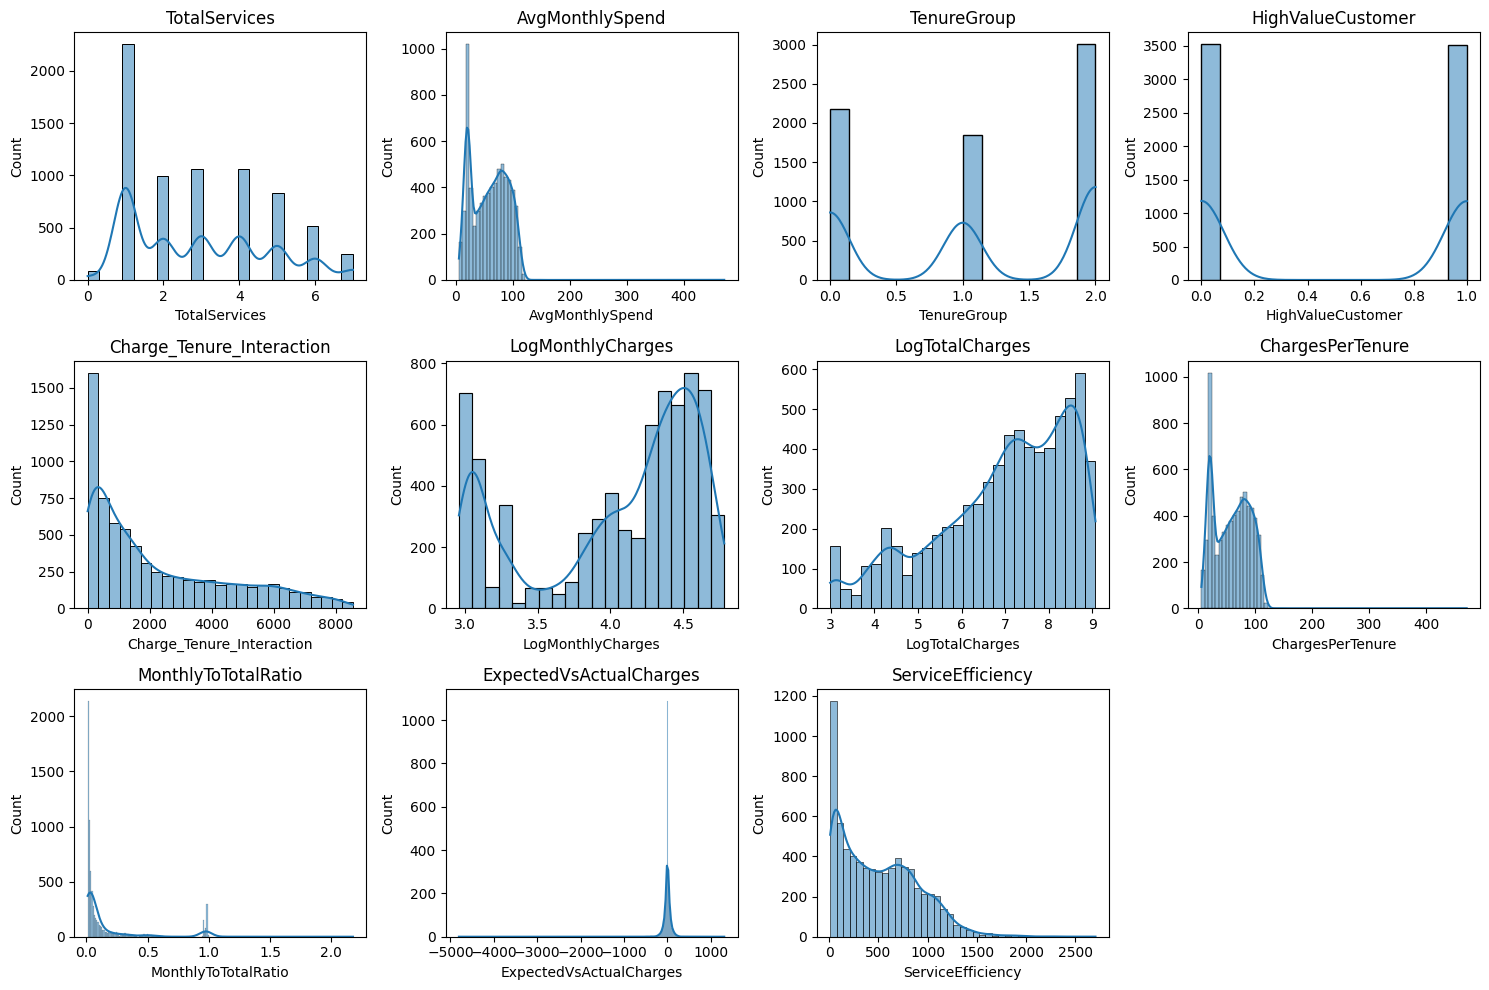

In [84]:
# ================================
# Distribution of Newly Engineered Features
# Shows how the new features are distributed after feature engineering
# Helps verify if transformations improved data shape or created skewness
# ================================

import seaborn as sns
import matplotlib.pyplot as plt

new_features = [
    'TotalServices','AvgMonthlySpend','TenureGroup',
    'HighValueCustomer','Charge_Tenure_Interaction',
    'LogMonthlyCharges','LogTotalCharges',
    'ChargesPerTenure','MonthlyToTotalRatio',
    'ExpectedVsActualCharges','ServiceEfficiency'
]

plt.figure(figsize=(15,10))

for i, col in enumerate(new_features):
    plt.subplot(3,4,i+1)
    sns.histplot(df[col], kde=True)
    plt.title(col)

plt.tight_layout()
plt.show()

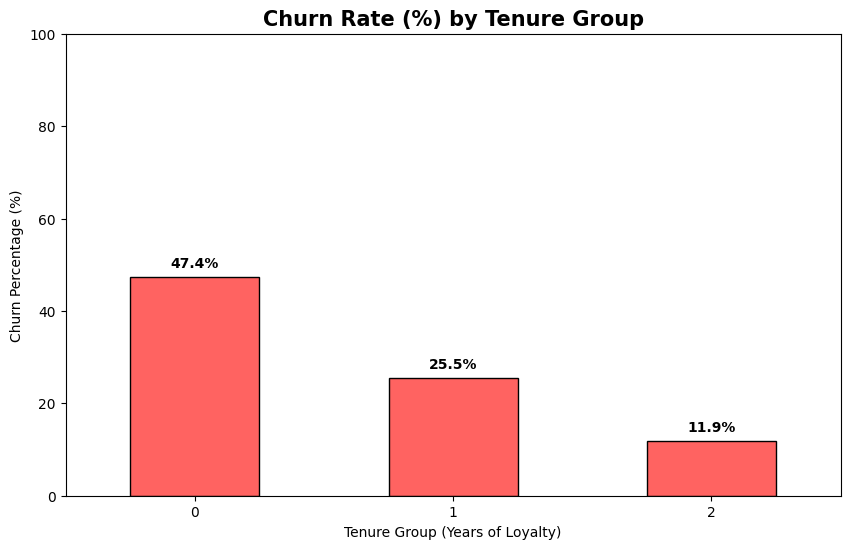

In [91]:
import matplotlib.pyplot as plt

churn_summary = df.groupby('TenureGroup')['Churn'].value_counts(normalize=True).unstack()

churn_col = 'Yes' if 'Yes' in churn_summary.columns else 1
churn_rate = churn_summary[churn_col] * 100

plt.figure(figsize=(10, 6))
churn_rate.plot(kind='bar', color='#ff6361', edgecolor='black', rot=0)

plt.title('Churn Rate (%) by Tenure Group', fontsize=15, fontweight='bold')
plt.xlabel('Tenure Group (Years of Loyalty)')
plt.ylabel('Churn Percentage (%)')
plt.ylim(0, 100)

for i, v in enumerate(churn_rate):
    plt.text(i, v + 2, f'{v:.1f}%', ha='center', fontweight='bold')

plt.show()

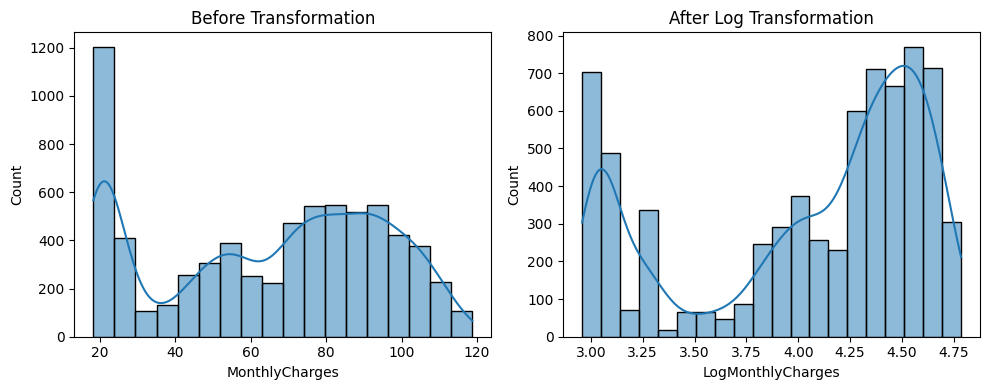

In [86]:
# ================================
# Before vs After Transformation
# Compares original vs log-transformed features
# Shows improvement in distribution (reducing skewness)
# ================================

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.histplot(df['MonthlyCharges'], kde=True)
plt.title("Before Transformation")

plt.subplot(1,2,2)
sns.histplot(df['LogMonthlyCharges'], kde=True)
plt.title("After Log Transformation")

plt.tight_layout()
plt.show()

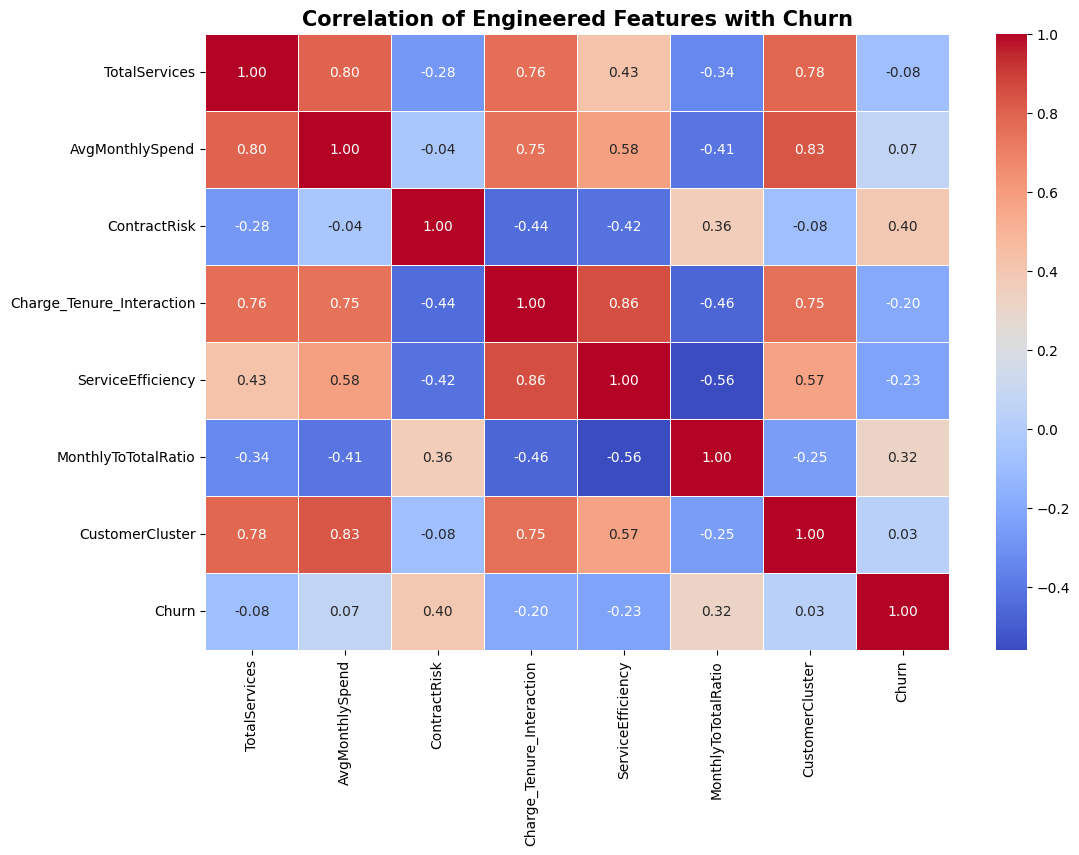

In [88]:
import seaborn as sns
import matplotlib.pyplot as plt

engineered_cols = [
    'TotalServices', 'AvgMonthlySpend', 'ContractRisk', 
    'Charge_Tenure_Interaction', 'ServiceEfficiency', 
    'MonthlyToTotalRatio', 'CustomerCluster', 'Churn'
]

plt.figure(figsize=(12, 8))
sns.heatmap(df[engineered_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Correlation of Engineered Features with Churn', fontsize=15, fontweight='bold')
plt.show()

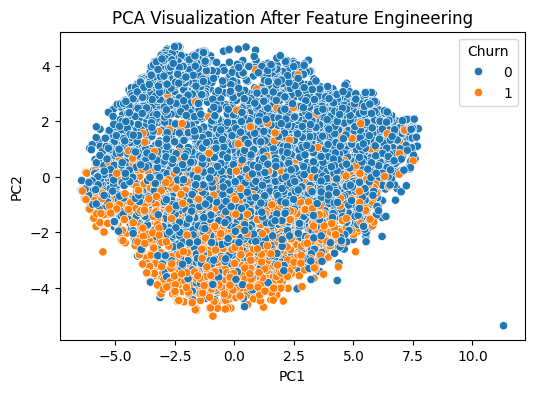

In [90]:
# ================================
# PCA Visualization
# Reduces high dimensional data into 2D/5D components
# Helps visualize patterns after feature engineering
# ================================

import seaborn as sns

plt.figure(figsize=(6,4))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='Churn')
plt.title("PCA Visualization After Feature Engineering")
plt.show()

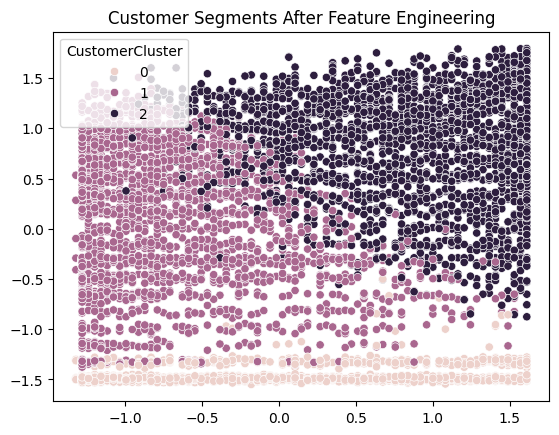

In [92]:
# ================================
# Customer Segmentation using KMeans
# Groups customers into behavior-based clusters
# Helps identify hidden patterns in engineered data
# ================================

import seaborn as sns

sns.scatterplot(x=X_scaled[:,0], y=X_scaled[:,1], hue=df['CustomerCluster'])
plt.title("Customer Segments After Feature Engineering")
plt.show()

In [94]:
# ================================
# Polynomial Features Overview
# Shows expanded feature space after polynomial transformation
# Helps understand interaction complexity between variables
# ================================

print("Original shape:", X_num.shape)
print("After Polynomial Features:", X_poly.shape)

poly_df.head()

Original shape: (7037, 3)
After Polynomial Features: (7037, 9)


,tenure,MonthlyCharges,TotalCharges,tenure^2,tenure MonthlyCharges,tenure TotalCharges,MonthlyCharges^2,MonthlyCharges TotalCharges,TotalCharges^2
0,-1.280885,-1.164399,-0.994707,1.640667,1.491461,1.274105,1.355824,1.158236,0.989442
1,0.063490,-0.262304,-0.174719,0.004031,-0.016654,-0.011093,0.068803,0.045830,0.030527
2,-1.240146,-0.365495,-0.960182,1.537963,0.453268,1.190766,0.133587,0.350942,0.921949
3,0.511615,-0.749968,-0.196215,0.261750,-0.383695,-0.100387,0.562451,0.147155,0.038500
4,-1.240146,0.195401,-0.941001,1.537963,-0.242326,1.166979,0.038182,-0.183873,0.885483


# Feature Selection

In [96]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.feature_selection import mutual_info_classif
from sklearn.ensemble import RandomForestClassifier

X = df.drop('Churn', axis=1)
y = df['Churn']
# Train & Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# METHOD 1: FILTER METHODS (Chi-Square + Mutual Info)

In [98]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [100]:
# Chi square
chi_selector = SelectKBest(score_func=chi2, k=10)
chi_selector.fit(X_train_scaled, y_train)

chi_scores = pd.DataFrame({
    'Feature': X_train.columns,
    'Score': chi_selector.scores_
}).sort_values(by='Score', ascending=False)

print("Chi_Square Top Features:")
print( chi_scores.head(10))

chi_features = X_train.columns[chi_selector.get_support()]

Chi_Square Top Features:
                           Feature       Score
12                        Contract  382.128874
21  PaymentMethod_Electronic check  277.197209
17     InternetService_Fiber optic  261.300880
34             MonthlyToTotalRatio  204.163819
29                    ContractRisk  199.179143
18              InternetService_No  189.557056
25                     TenureGroup  184.112858
4                           tenure  156.584060
1                    SeniorCitizen  107.670927
28               HighValueCustomer  100.208292


In [102]:
# Mutual Information
mi_selector = SelectKBest(score_func=mutual_info_classif, k=10)
mi_selector.fit(X_train, y_train)

mi_scores = pd.DataFrame({
    'Feature': X_train.columns,
    'Score': mi_selector.scores_
}).sort_values(by='Score', ascending=False)

print("Mutual Information Top Features:")
print(mi_scores.head(10))

mi_features = X_train.columns[mi_selector.get_support()]

Mutual Information Top Features:
                        Feature     Score
29                 ContractRisk  0.095430
12                     Contract  0.090568
34          MonthlyToTotalRatio  0.083651
37              CustomerCluster  0.071652
4                        tenure  0.069577
25                  TenureGroup  0.063914
36            ServiceEfficiency  0.058395
17  InternetService_Fiber optic  0.057749
14               MonthlyCharges  0.050486
31            LogMonthlyCharges  0.049274


In [104]:
# Comparing chi square & mutual info
chi_set = set(chi_features)
mi_set = set(mi_features)

print("Common Features:", chi_set & mi_set)
print("Chi only:", chi_set - mi_set)
print("MI only:", mi_set - chi_set)

Common Features: {'InternetService_Fiber optic', 'Contract', 'ContractRisk', 'tenure', 'TenureGroup', 'MonthlyToTotalRatio'}
Chi only: {'HighValueCustomer', 'PaymentMethod_Electronic check', 'InternetService_No', 'SeniorCitizen'}
MI only: {'CustomerCluster', 'MonthlyCharges', 'LogMonthlyCharges', 'ServiceEfficiency'}


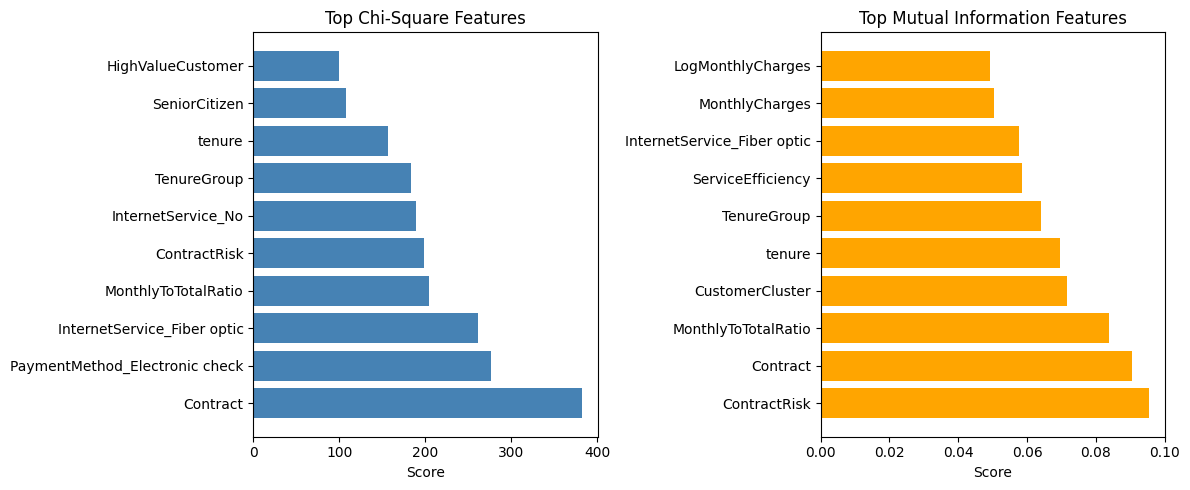

In [106]:
import matplotlib.pyplot as plt

top_k = 10

top_chi = chi_scores.head(top_k)
top_mi = mi_scores.head(top_k)

plt.figure(figsize=(12,5))

# Chi-Square Top Features
plt.subplot(1,2,1)
plt.barh(top_chi['Feature'], top_chi['Score'], color='steelblue')
plt.title("Top Chi-Square Features")
plt.xlabel("Score")

# Mutual Information Top Features
plt.subplot(1,2,2)
plt.barh(top_mi['Feature'], top_mi['Score'], color='orange')
plt.title("Top Mutual Information Features")
plt.xlabel("Score")

plt.tight_layout()
plt.show()

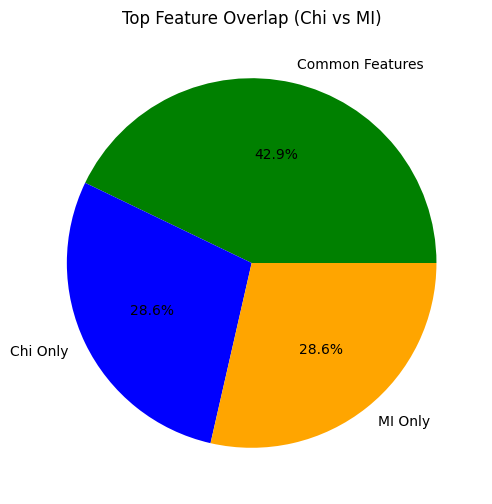

In [108]:
# ============================================
# Feature Agreement Visualization
# This plot shows the overlap between top features
# selected by Chi-Square and Mutual Information methods.
# It helps understand how much both methods agree on important features.
# ============================================

import matplotlib.pyplot as plt

chi_set = set(top_chi['Feature'])
mi_set = set(top_mi['Feature'])

labels = ['Common Features', 'Chi Only', 'MI Only']
sizes = [
    len(chi_set & mi_set),
    len(chi_set - mi_set),
    len(mi_set - chi_set)
]

plt.figure(figsize=(6,6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', colors=['green','blue','orange'])
plt.title("Top Feature Overlap (Chi vs MI)")
plt.show()

# METHOD 2: EMBEDDED (Random Forest Importance)

In [110]:
# Random Forest Importance
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("Top Embedded Features:")
print(importances.head(10))

Top Embedded Features:
                      Feature  Importance
34        MonthlyToTotalRatio    0.081041
36          ServiceEfficiency    0.069711
14             MonthlyCharges    0.068343
31          LogMonthlyCharges    0.062468
32            LogTotalCharges    0.060149
15               TotalCharges    0.059417
27            AvgMonthlySpend    0.059056
30  Charge_Tenure_Interaction    0.056916
33           ChargesPerTenure    0.056591
35    ExpectedVsActualCharges    0.052077


In [112]:
embedded_features = importances.head(10)['Feature'].values
print(list(embedded_features))

['MonthlyToTotalRatio', 'ServiceEfficiency', 'MonthlyCharges', 'LogMonthlyCharges', 'LogTotalCharges', 'TotalCharges', 'AvgMonthlySpend', 'Charge_Tenure_Interaction', 'ChargesPerTenure', 'ExpectedVsActualCharges']


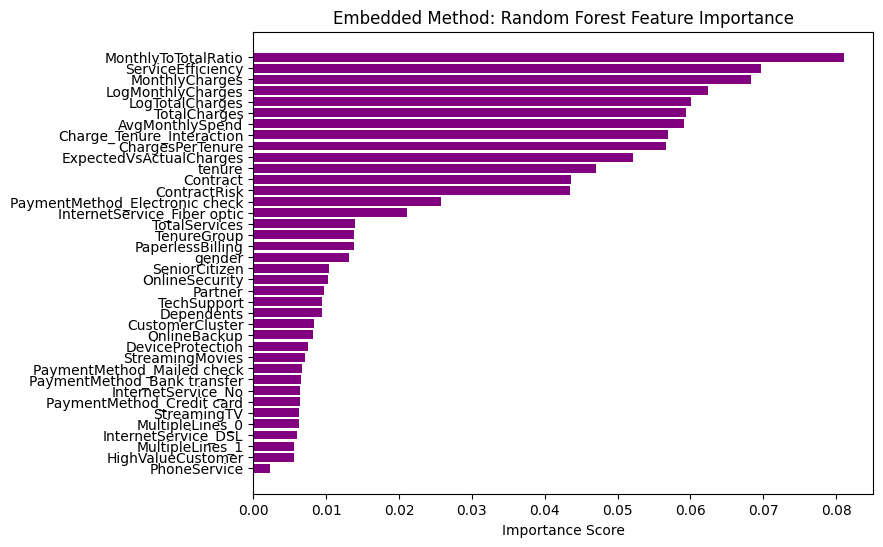

In [114]:
# ============================================
# Embedded Feature Selection Visualization
# (Random Forest Feature Importance)
#
# This visualization shows feature importance
# calculated from a trained Random Forest model.
# It ranks features based on how much they
# contribute to prediction accuracy.
# ============================================

import matplotlib.pyplot as plt

# Sort features by importance
importances = importances.sort_values(by='Importance', ascending=True)

plt.figure(figsize=(8,6))

plt.barh(importances['Feature'], importances['Importance'], color='purple')

plt.title("Embedded Method: Random Forest Feature Importance")
plt.xlabel("Importance Score")

plt.show()

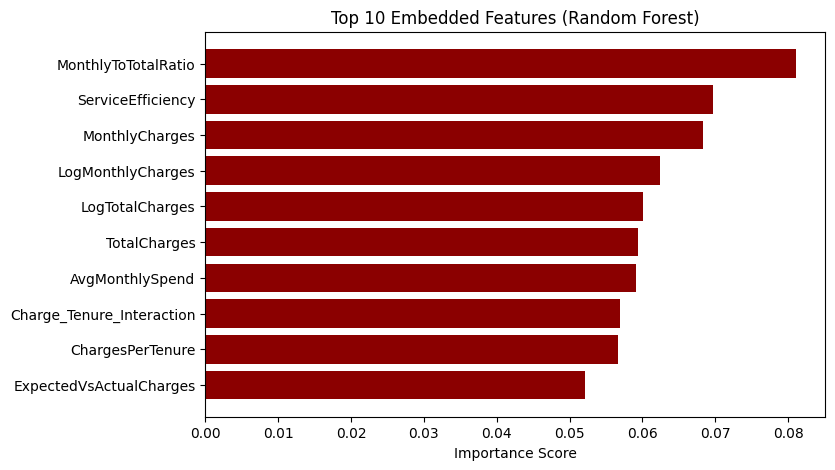

In [116]:
# ============================================
# Top Embedded Features Visualization
# Shows only the most important features
# according to Random Forest model
# ============================================

top_embedded = importances.sort_values(by='Importance', ascending=False).head(10)

plt.figure(figsize=(8,5))

plt.barh(top_embedded['Feature'], top_embedded['Importance'], color='darkred')

plt.title("Top 10 Embedded Features (Random Forest)")
plt.xlabel("Importance Score")

plt.gca().invert_yaxis()  # highest on top

plt.show()

# Comparison between Filter and Embedded

In [118]:
filter_features = set(mi_features)   #  or chi_features
embedded_features_set = set(embedded_features)

print("Common Features:")
print(filter_features & embedded_features_set)

print("\nOnly Filter Methods:")
print(filter_features - embedded_features_set)

print("\nOnly Embedded Method:")
print(embedded_features_set - filter_features)

Common Features:
{'MonthlyToTotalRatio', 'ServiceEfficiency', 'LogMonthlyCharges', 'MonthlyCharges'}

Only Filter Methods:
{'InternetService_Fiber optic', 'Contract', 'ContractRisk', 'tenure', 'CustomerCluster', 'TenureGroup'}

Only Embedded Method:
{'AvgMonthlySpend', 'Charge_Tenure_Interaction', 'LogTotalCharges', 'ExpectedVsActualCharges', 'TotalCharges', 'ChargesPerTenure'}


In [124]:
# ============================================
# Prepare feature sets for comparison:
# Filter methods (Chi2 + MI intersection)
# Embedded method (Random Forest)
# ============================================

filter_features = set(final_features)   # intersection of Chi & MI
embedded_features = set(embedded_features)

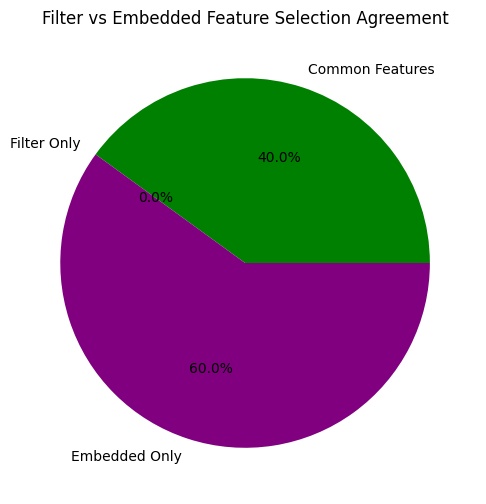

In [126]:
# ============================================
# Feature Selection Comparison Visualization
# Shows overlap between:
# - Filter Methods (Chi2 + MI)
# - Embedded Method (Random Forest)
# Helps understand agreement between approaches
# ============================================

import matplotlib.pyplot as plt

common = len(filter_features & embedded_features)
filter_only = len(filter_features - embedded_features)
embedded_only = len(embedded_features - filter_features)

labels = ['Common Features', 'Filter Only', 'Embedded Only']
sizes = [common, filter_only, embedded_only]

plt.figure(figsize=(6,6))
plt.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',
    colors=['green', 'blue', 'purple']
)

plt.title("Filter vs Embedded Feature Selection Agreement")
plt.show()

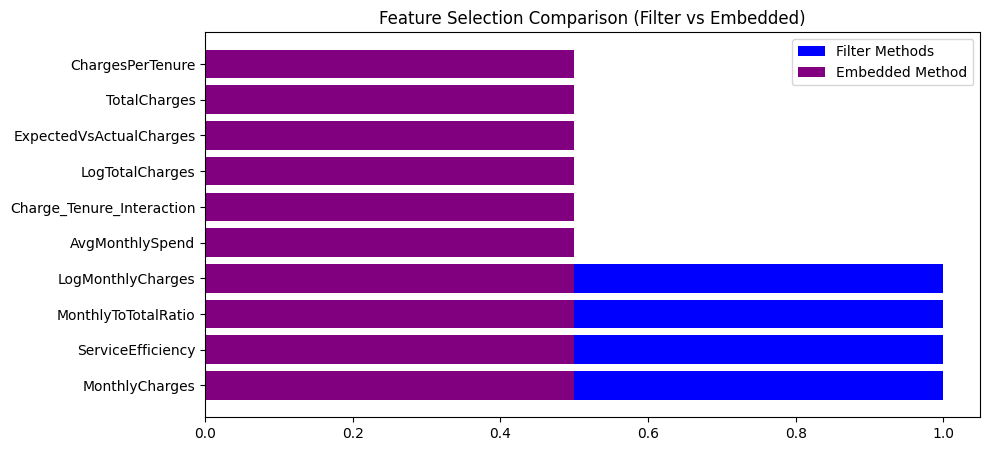

In [128]:
# ============================================
# Side-by-side comparison of top features
# from Filter vs Embedded methods
# ============================================

import matplotlib.pyplot as plt

filter_list = list(filter_features)
embedded_list = list(embedded_features)

plt.figure(figsize=(10,5))

plt.barh(filter_list, [1]*len(filter_list), color='blue', label='Filter Methods')
plt.barh(embedded_list, [0.5]*len(embedded_list), color='purple', label='Embedded Method')

plt.title("Feature Selection Comparison (Filter vs Embedded)")
plt.legend()
plt.show()

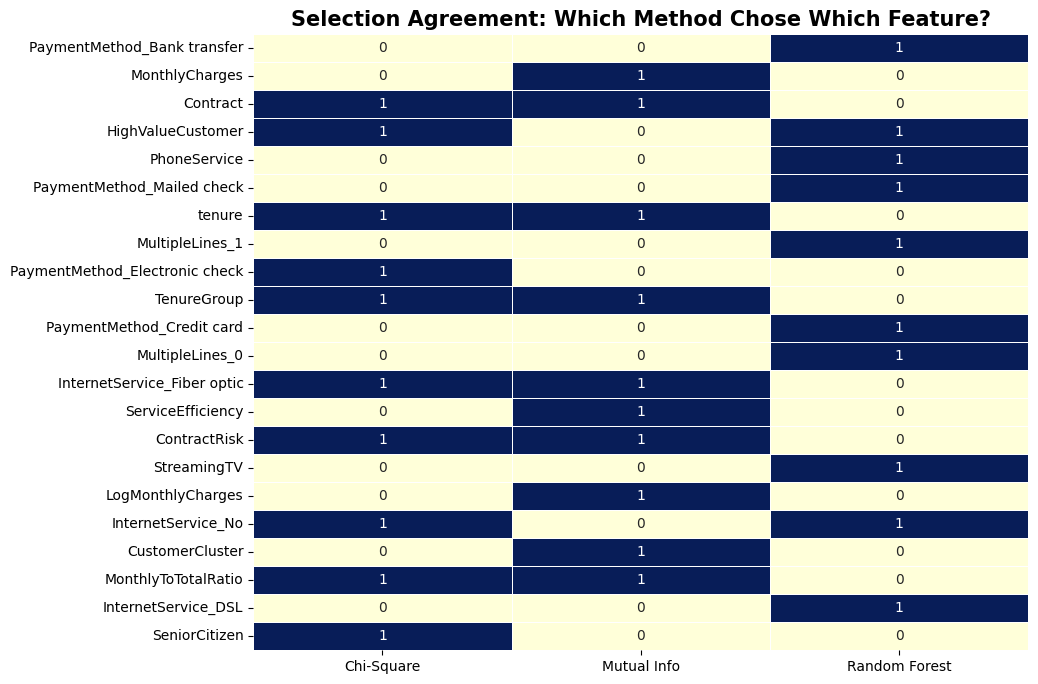

In [130]:
import pandas as pd
import seaborn as sns


all_top_features = list(set(chi_scores.head(10)['Feature']) | set(mi_scores.head(10)['Feature']) | set(importances.head(10)['Feature']))
comparison_df = pd.DataFrame(index=all_top_features)

comparison_df['Chi-Square'] = comparison_df.index.isin(chi_scores.head(10)['Feature'])
comparison_df['Mutual Info'] = comparison_df.index.isin(mi_scores.head(10)['Feature'])
comparison_df['Random Forest'] = comparison_df.index.isin(importances.head(10)['Feature'])

plt.figure(figsize=(10, 8))
sns.heatmap(comparison_df, annot=True, cmap="YlGnBu", cbar=False, linewidths=0.5)
plt.title('Selection Agreement: Which Method Chose Which Feature?', fontsize=15, fontweight='bold')
plt.show()

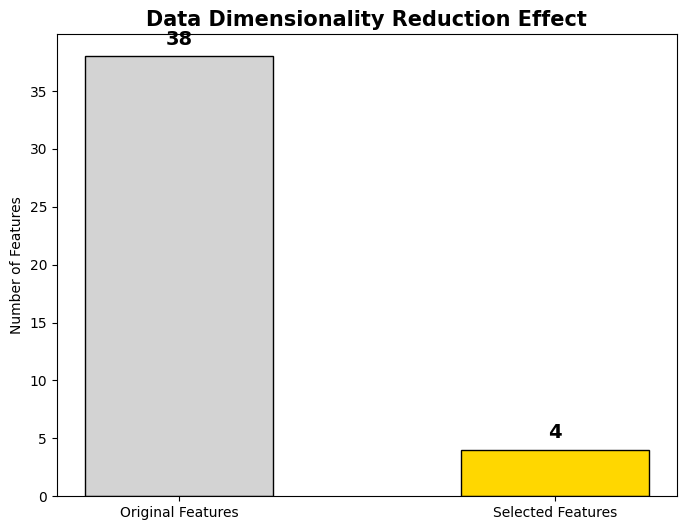

In [132]:
labels = ['Original Features', 'Selected Features']

counts = [X_train.shape[1], X_train_selected.shape[1]]

plt.figure(figsize=(8, 6))
bars = plt.bar(labels, counts, color=['lightgrey', 'gold'], edgecolor='black', width=0.5)

plt.title('Data Dimensionality Reduction Effect', fontsize=15, fontweight='bold')
plt.ylabel('Number of Features')


for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, int(yval), ha='center', fontweight='bold', fontsize=14)

plt.show()

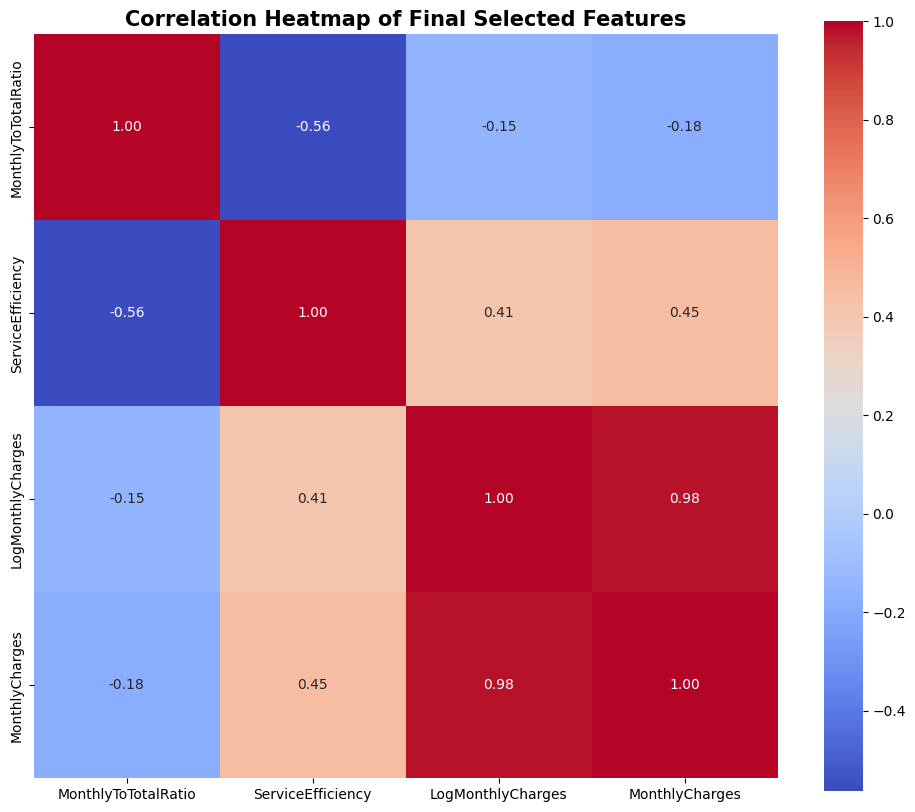

In [134]:
plt.figure(figsize=(12, 10))

final_corr = X_train_selected.corr()

sns.heatmap(final_corr, annot=True, cmap='coolwarm', fmt=".2f", square=True)
plt.title('Correlation Heatmap of Final Selected Features', fontsize=15, fontweight='bold')
plt.show()

# FINAL SELECTED DATASET

In [136]:
final_features = list(filter_features & embedded_features_set)

X_train_selected = X_train[final_features]
X_test_selected = X_test[final_features]

print("Final Selected Features:", final_features)
print("Shape:", X_train_selected.shape)
X_train_selected.head()


Final Selected Features: ['LogMonthlyCharges', 'MonthlyCharges', 'MonthlyToTotalRatio', 'ServiceEfficiency']
Shape: (4925, 4)


,LogMonthlyCharges,MonthlyCharges,MonthlyToTotalRatio,ServiceEfficiency
4790,4.452602,84.85,0.032208,877.800000
6964,4.048301,56.30,0.020240,556.120000
3097,3.063391,20.40,0.464692,21.450000
6546,3.954124,51.15,0.040064,425.233333
2871,4.467057,86.10,0.069629,411.850000


In [107]:
!pip install skrebate

In [138]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SequentialFeatureSelector, RFE
from sklearn.model_selection import cross_val_score
from skrebate import ReliefF
import time
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# فصل البيانات
X = df.drop("Churn", axis=1)
y = df["Churn"]

# Encoding
X = pd.get_dummies(X, drop_first=True)

if y.dtype == "object":
    y = LabelEncoder().fit_transform(y)

model = LogisticRegression(max_iter=5000)

In [140]:
# 1. Relief Method (Modified to fix KeyError)
from skrebate import ReliefF
start_time=time.time()

y_reset = pd.Series(y).reset_index(drop=True)
X_values = X.values # تحويل X لمصفوفة numpy

relief = ReliefF(n_features_to_select=10, n_neighbors=100)

relief.fit(X_values, y_reset.values)

relief_indices = relief.top_features_[:10]
relief_features = X.columns[relief_indices].tolist()
end_time=time.time()

execution_time = end_time - start_time

print("Execution Time:", round(execution_time, 4), "seconds")

print("Top 10 Features (ReliefF):")
print(relief_features)

Execution Time: 91.8674 seconds
Top 10 Features (ReliefF):
['Contract', 'ContractRisk', 'LogTotalCharges', 'TenureGroup', 'MonthlyToTotalRatio', 'tenure', 'ServiceEfficiency', 'InternetService_DSL', 'InternetService_Fiber optic', 'Partner']


In [142]:
#feature selection (Reliff method)

relief = ReliefF(n_features_to_select=10, n_neighbors=100)
relief.fit(X_values, y_reset.values)

import pandas as pd

relief_results = pd.DataFrame({
    'Feature': X.columns,
    'Relief_Score': relief.feature_importances_
})


relief_results = relief_results.sort_values(by='Relief_Score', ascending=False)

print("ReliefF Scores for all features:")
print(relief_results.head(10))


ReliefF Scores for all features:
                        Feature  Relief_Score
29                 ContractRisk      0.212655
12                     Contract      0.212655
32              LogTotalCharges      0.141260
25                  TenureGroup      0.140244
34          MonthlyToTotalRatio      0.117661
4                        tenure      0.113402
36            ServiceEfficiency      0.102414
16          InternetService_DSL      0.071695
17  InternetService_Fiber optic      0.068283
2                       Partner      0.061863


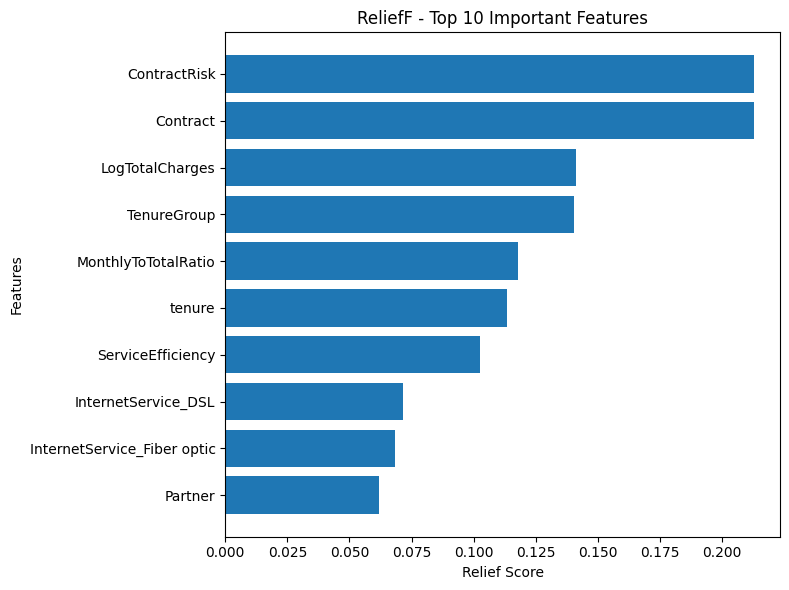

In [146]:
# ==========================================
# Top 10 Features Importance (ReliefF)
# This plot shows the top 10 most important features
# selected by the ReliefF algorithm based on their scores
# ==========================================

import matplotlib.pyplot as plt

top10 = relief_results.head(10)

plt.figure(figsize=(8,6))
plt.barh(top10['Feature'], top10['Relief_Score'])
plt.gca().invert_yaxis()

plt.title("ReliefF - Top 10 Important Features")
plt.xlabel("Relief Score")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

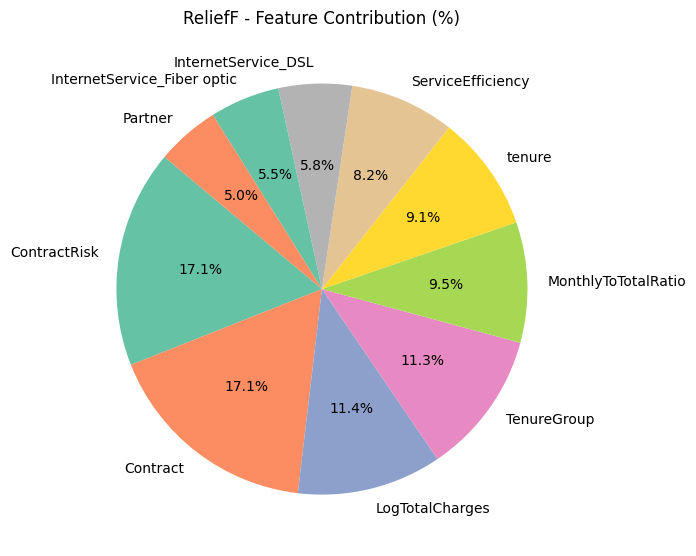

In [148]:
import matplotlib.pyplot as plt
import seaborn as sns

relief_results['Importance_%'] = (
    relief_results['Relief_Score'] /
    relief_results['Relief_Score'].sum()
) * 100

top10 = relief_results.head(10)

colors = sns.color_palette("Set2", len(top10))

plt.figure(figsize=(7,7))
plt.pie(
    top10['Importance_%'],
    labels=top10['Feature'],
    autopct='%1.1f%%',
    startangle=140,
    colors=colors
)

plt.title("ReliefF - Feature Contribution (%)")
plt.tight_layout()
plt.show()

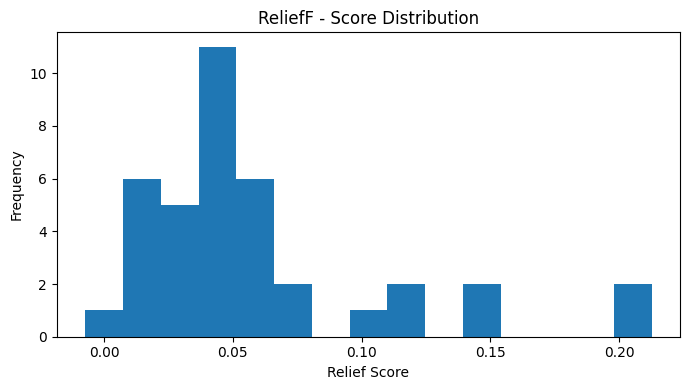

In [150]:
# ==========================================
# Feature Score Distribution
# This histogram shows how ReliefF scores
# are distributed across all features
# ==========================================

import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))
plt.hist(relief_results['Relief_Score'], bins=15)

plt.title("ReliefF - Score Distribution")
plt.xlabel("Relief Score")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

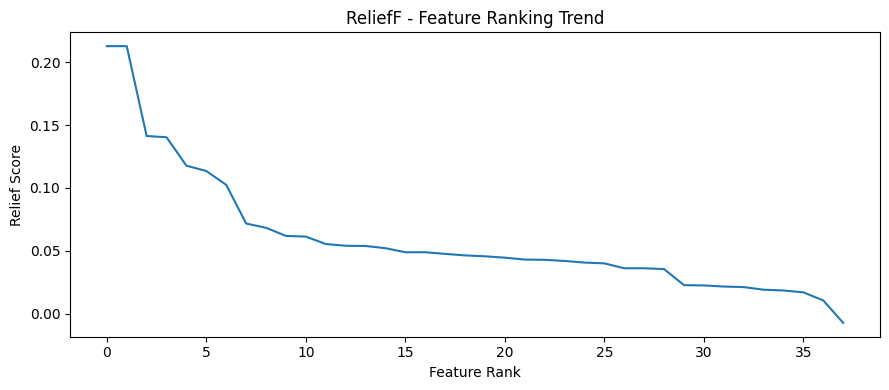

In [152]:
# ==========================================
# Feature Ranking Trend
# This line plot shows the ranking trend
# of all features based on ReliefF scores
# ==========================================

import matplotlib.pyplot as plt

plt.figure(figsize=(9,4))
plt.plot(relief_results['Relief_Score'].values)

plt.title("ReliefF - Feature Ranking Trend")
plt.xlabel("Feature Rank")
plt.ylabel("Relief Score")
plt.tight_layout()
plt.show()

In [154]:
#feature selection wrapper method (forward)
# ==========================================
# Forward Selection Algorithm
# Selects best features step-by-step
# based on model performance
# ==========================================

from sklearn.feature_selection import SequentialFeatureSelector
import pandas as pd
start_time=time.time()
forward = SequentialFeatureSelector(
    model,
    n_features_to_select=10,
    direction="forward"
)

forward.fit(X, y)

forward_features = X.columns[forward.get_support()]

model.fit(X[forward_features], y)

forward_importance = pd.Series(
    abs(model.coef_[0]),
    index=forward_features
).sort_values(ascending=False)
end_time=time.time()

execution_time = end_time - start_time

print("Execution Time:", round(execution_time, 4), "seconds")
print("Top Features (Forward Selection):")
print(forward_importance)


Execution Time: 169.7411 seconds
Top Features (Forward Selection):
MonthlyToTotalRatio           1.486961
PhoneService                  1.013776
Contract                      0.939153
OnlineSecurity                0.567271
PaymentMethod_Mailed check    0.394965
PaperlessBilling              0.380510
PaymentMethod_Credit card     0.285192
LogMonthlyCharges             0.232324
MonthlyCharges                0.037059
tenure                        0.024508
dtype: float64


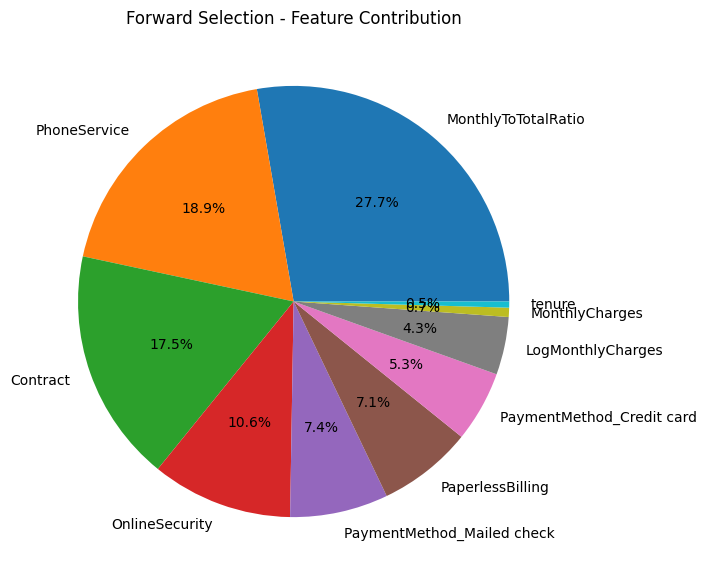

In [156]:
# ==========================================
# Pie Chart - Feature Contribution
# Shows percentage contribution of each feature
# to the model based on importance values
# ==========================================

import matplotlib.pyplot as plt

contribution = (forward_importance / forward_importance.sum()) * 100

plt.figure(figsize=(7,7))
plt.pie(
    contribution,
    labels=contribution.index,
    autopct='%1.1f%%'
)

plt.title("Forward Selection - Feature Contribution")
plt.show()

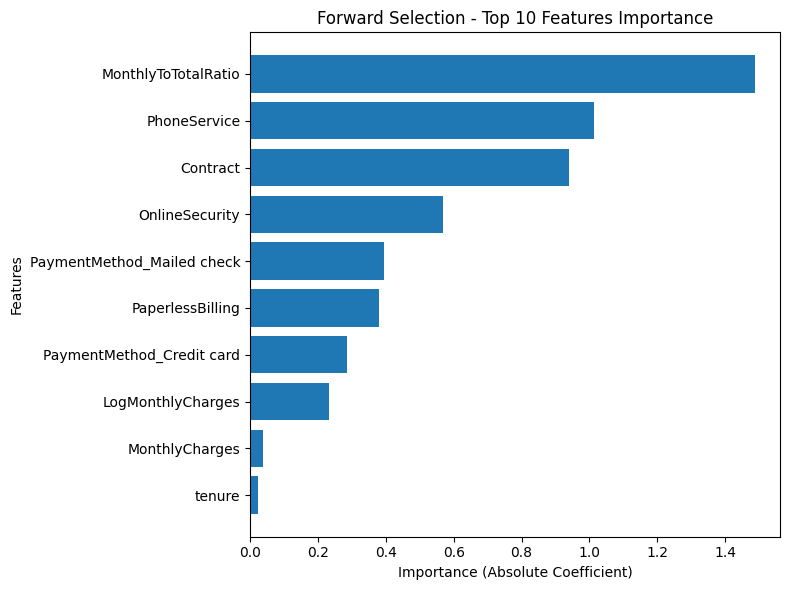

In [158]:
# ==========================================
# Bar Chart - Top Feature Importance
# Shows the most important features selected
# by Forward Selection with their scores
# ==========================================

top10 = forward_importance.head(10)

plt.figure(figsize=(8,6))
plt.barh(top10.index, top10.values)
plt.gca().invert_yaxis()

plt.title("Forward Selection - Top 10 Features Importance")
plt.xlabel("Importance (Absolute Coefficient)")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

feature selection wrapper method( Backward Elimination)

In [160]:
#feature selection wrapper method( Backward Elimination)
# ==========================================
# Backward Elimination - Fixed Core Logic Only
# Assumes X_scaled and model already defined
# ==========================================
start_time=time.time()
backward = SequentialFeatureSelector(
    model,
    n_features_to_select=10,
    direction="backward"
)

backward.fit(X_scaled, y)

backward_features = X_scaled.columns[backward.get_support()]

model.fit(X_scaled[backward_features], y)

backward_importance = pd.Series(
    abs(model.coef_[0]),
    index=backward_features
).sort_values(ascending=False)
end_time=time.time()

execution_time = end_time - start_time

print("Execution Time:", round(execution_time, 4), "seconds")
print("Top Features (Backward Elimination):")
print(backward_importance)

Execution Time: 145.5404 seconds
Top Features (Backward Elimination):
MonthlyCharges                    1.803005
ChargesPerTenure                  0.923422
ContractRisk                      0.689197
tenure                            0.596369
PhoneService                      0.333369
OnlineSecurity                    0.240226
TechSupport                       0.235768
PaymentMethod_Electronic check    0.156091
OnlineBackup                      0.121876
MultipleLines_1                   0.118149
dtype: float64


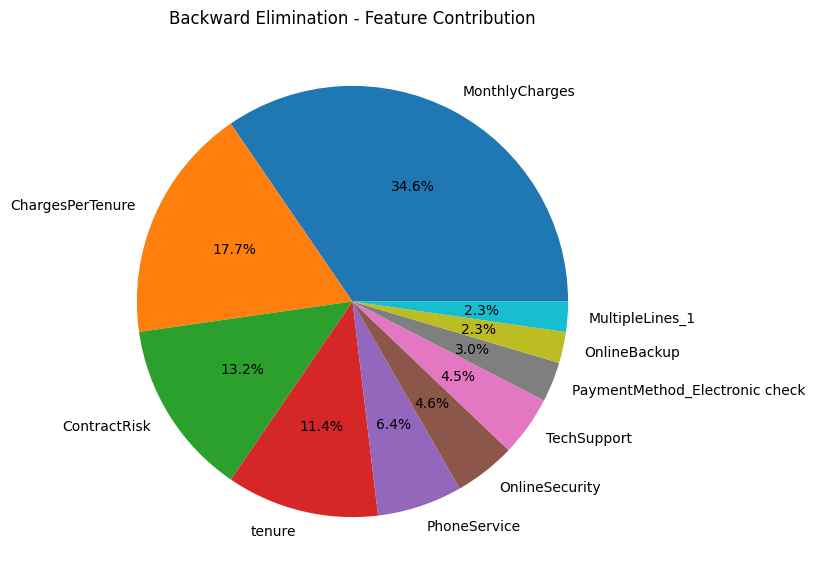

In [162]:
# ==========================================
# Backward Elimination - Feature Contribution
# Shows percentage contribution of each selected feature
# based on their importance values
# ==========================================

contribution = (backward_importance / backward_importance.sum()) * 100

plt.figure(figsize=(7,7))
plt.pie(
    contribution,
    labels=contribution.index,
    autopct='%1.1f%%'
)

plt.title("Backward Elimination - Feature Contribution")
plt.show()

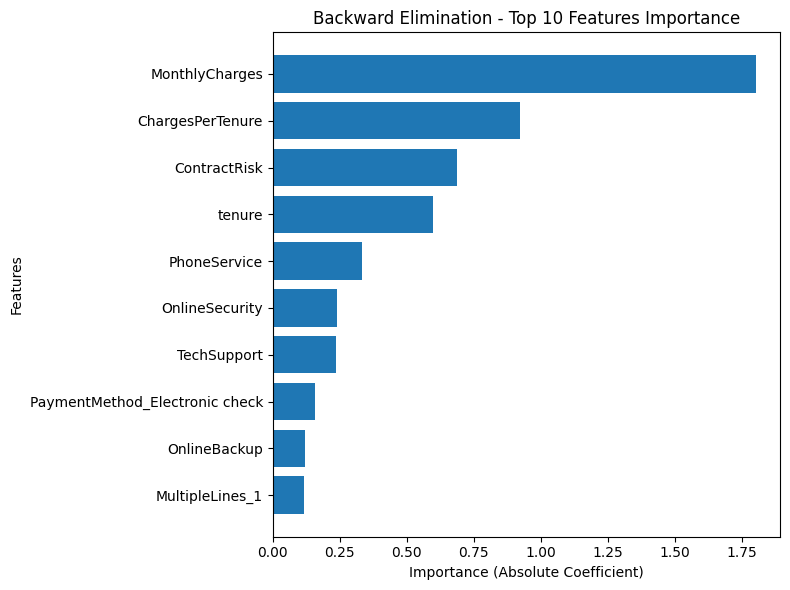

In [164]:
# ==========================================
# Backward Elimination - Top Features Importance
# Shows the most important features selected
# by Backward Elimination with their scores
# ==========================================

top10 = backward_importance.head(10)

plt.figure(figsize=(8,6))
plt.barh(top10.index, top10.values)
plt.gca().invert_yaxis()

plt.title("Backward Elimination - Top 10 Features Importance")
plt.xlabel("Importance (Absolute Coefficient)")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

In [166]:
# ==========================================
# Collecting Feature Selection Results
# For comparison between ReliefF, Forward, Backward
# ==========================================

relief_top = relief_results.head(10)

forward_top = pd.DataFrame({
    "Feature": forward_features,
    "Score": forward_importance.values
}).sort_values(by="Score", ascending=False)

backward_top = pd.DataFrame({
    "Feature": backward_features,
    "Score": backward_importance.values
}).sort_values(by="Score", ascending=False)

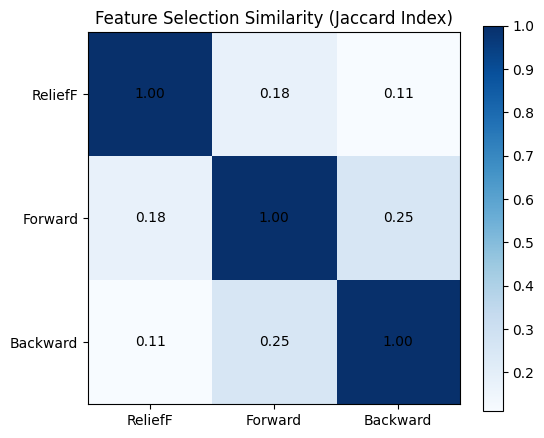

In [168]:
# ==========================================
# Feature Overlap Between Methods
# Shows how similar selected features are
# across different algorithms
# ==========================================

import numpy as np
import matplotlib.pyplot as plt

relief_set = set(relief_top["Feature"])
forward_set = set(forward_features)
backward_set = set(backward_features)

methods = ["ReliefF", "Forward", "Backward"]
sets = [relief_set, forward_set, backward_set]

similarity = np.zeros((3,3))

for i in range(3):
    for j in range(3):
        similarity[i, j] = len(sets[i].intersection(sets[j])) / len(sets[i].union(sets[j]))

plt.figure(figsize=(6,5))
plt.imshow(similarity, cmap="Blues")

plt.xticks(range(3), methods)
plt.yticks(range(3), methods)

plt.title("Feature Selection Similarity (Jaccard Index)")

for i in range(3):
    for j in range(3):
        plt.text(j, i, f"{similarity[i,j]:.2f}", ha="center", va="center")

plt.colorbar()
plt.show()

In [170]:
# ==========================================
# Common Features Across All Methods
# Shows intersection of selected features
# ==========================================

common_features = relief_set.intersection(forward_set).intersection(backward_set)

print("Common Features Across All Methods:")
print(list(common_features))

Common Features Across All Methods:
['tenure']


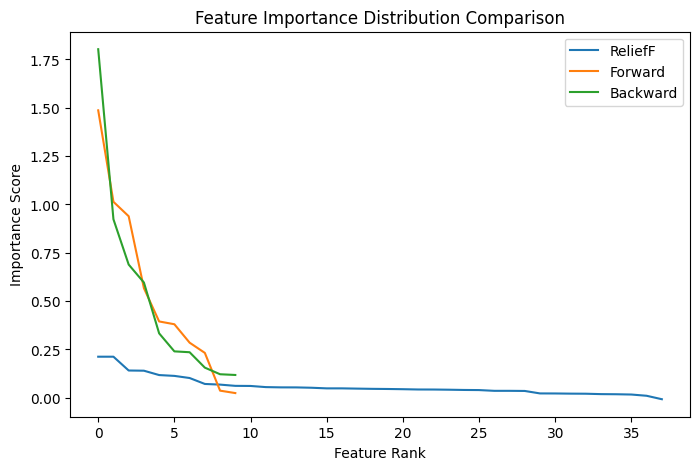

In [172]:
# ==========================================
# Feature Importance Distribution Comparison
# Compares how each method distributes importance
# ==========================================

plt.figure(figsize=(8,5))

plt.plot(relief_results["Relief_Score"].values, label="ReliefF")
plt.plot(forward_importance.values, label="Forward")
plt.plot(backward_importance.values, label="Backward")

plt.title("Feature Importance Distribution Comparison")
plt.xlabel("Feature Rank")
plt.ylabel("Importance Score")
plt.legend()

plt.show()

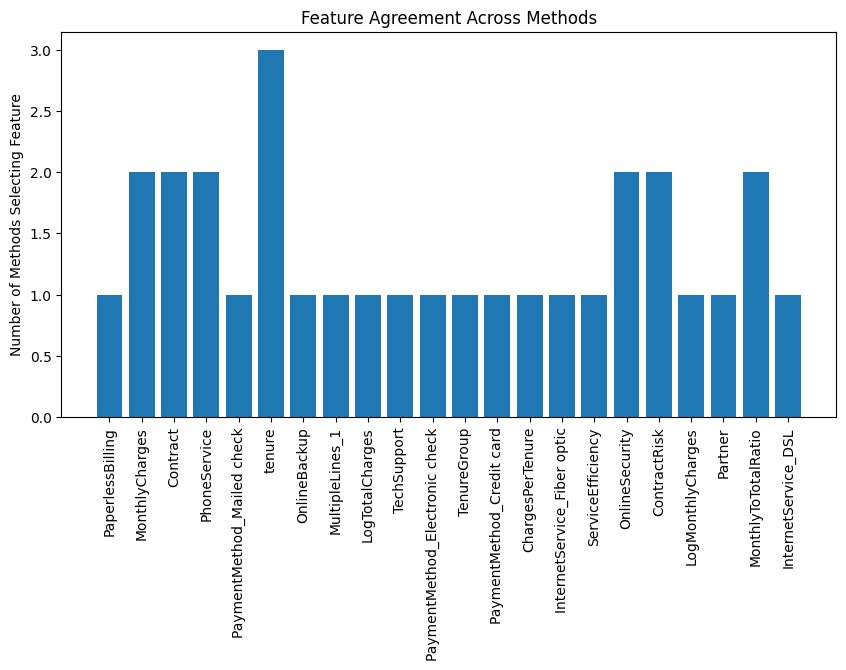

In [174]:
# ==========================================
# Top Features Agreement Visualization
# Shows how often features appear in all methods
# ==========================================

all_features = list(relief_set | forward_set | backward_set)

votes = []

for f in all_features:
    count = 0
    if f in relief_set:
        count += 1
    if f in forward_set:
        count += 1
    if f in backward_set:
        count += 1
    votes.append(count)

plt.figure(figsize=(10,5))
plt.bar(all_features, votes)

plt.title("Feature Agreement Across Methods")
plt.ylabel("Number of Methods Selecting Feature")
plt.xticks(rotation=90)
plt.show()

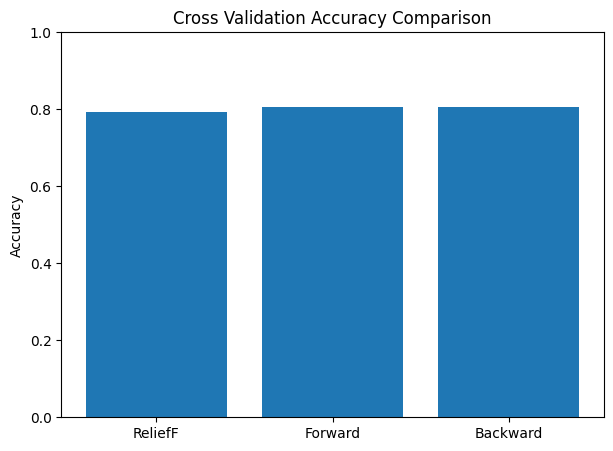

ReliefF Accuracy: 0.7933755532402921
Forward Accuracy: 0.8055975197066614
Backward Accuracy: 0.8064510039090262


In [176]:
# ==========================================
# Cross Validation Comparison
# Compares model performance across methods
# ==========================================

from sklearn.model_selection import cross_val_score

X_relief = X[relief_top["Feature"]]
X_forward = X[forward_top["Feature"]]
X_backward = X_scaled[backward_top["Feature"]]

cv_relief = cross_val_score(model, X_relief, y, cv=5).mean()
cv_forward = cross_val_score(model, X_forward, y, cv=5).mean()
cv_backward = cross_val_score(model, X_backward, y, cv=5).mean()

methods = ["ReliefF", "Forward", "Backward"]
scores = [cv_relief, cv_forward, cv_backward]

plt.figure(figsize=(7,5))
plt.bar(methods, scores)

plt.title("Cross Validation Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0,1)
plt.show()

print("ReliefF Accuracy:", cv_relief)
print("Forward Accuracy:", cv_forward)
print("Backward Accuracy:", cv_backward)

In [178]:

# Final Best Method Selection
# Creates final dataset using best method
# ==========================================

best_method = max(
    [("ReliefF", cv_relief),
     ("Forward", cv_forward),
     ("Backward", cv_backward)],
    key=lambda x: x[1]
)[0]

print("Best Method:", best_method)

if best_method == "ReliefF":
    final_X = X[relief_top["Feature"]]
elif best_method == "Forward":
    final_X = X[forward_features]
else:
    final_X = X_scaled[backward_features]

final_dataset = final_X.copy()
final_dataset["Target"] = y

# Display as DataFrame
display(final_dataset.head())

Best Method: Backward


,tenure,PhoneService,OnlineSecurity,OnlineBackup,TechSupport,MonthlyCharges,PaymentMethod_Electronic check,MultipleLines_1,ContractRisk,ChargesPerTenure,Target
0,-1.280885,-3.077617,-0.625949,1.398829,-0.631669,-1.164399,1.356811,-0.835289,0.827755,-1.427558,0.0
1,0.063490,0.324927,1.597575,-0.714884,-0.631669,-0.262304,-0.737022,-0.835289,-0.371527,-0.169002,0.0
2,-1.240146,0.324927,1.597575,1.398829,-0.631669,-0.365495,-0.737022,-0.835289,0.827755,-0.746900,1.0
3,0.511615,-3.077617,1.597575,-0.714884,1.583107,-0.749968,-0.737022,-0.835289,-0.371527,-0.619104,0.0
4,-1.240146,0.324927,-0.625949,-0.714884,-0.631669,0.195401,1.356811,-0.835289,0.827755,-0.279703,1.0
